# Cenário I

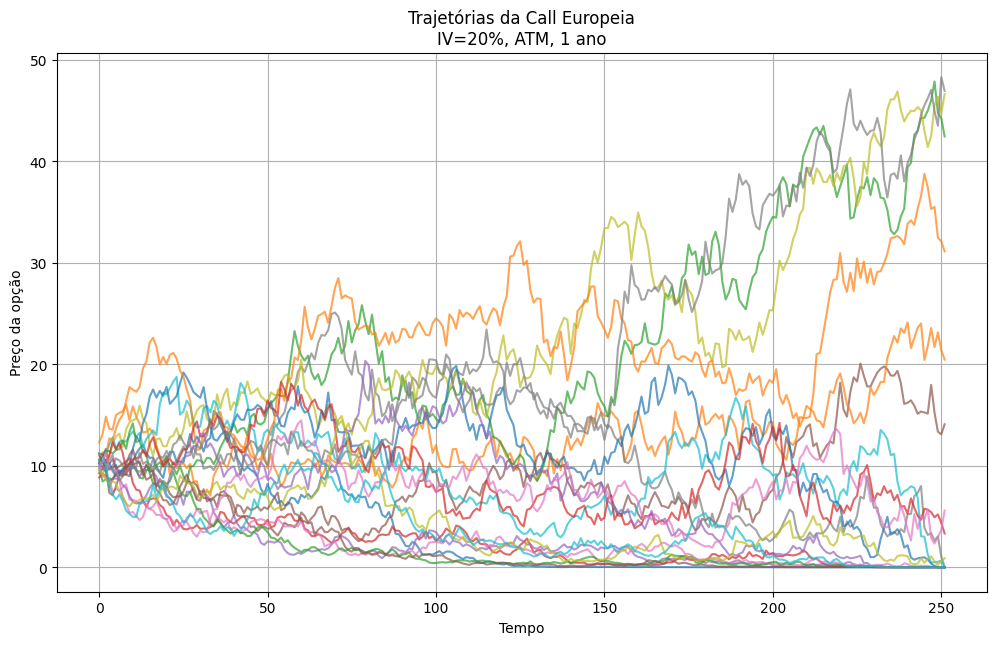

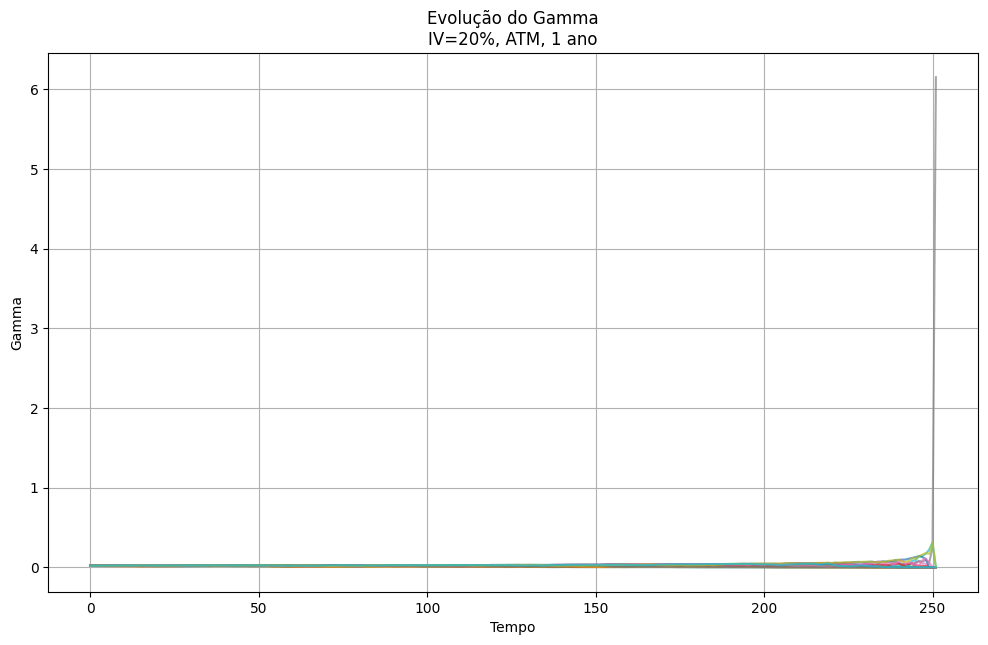

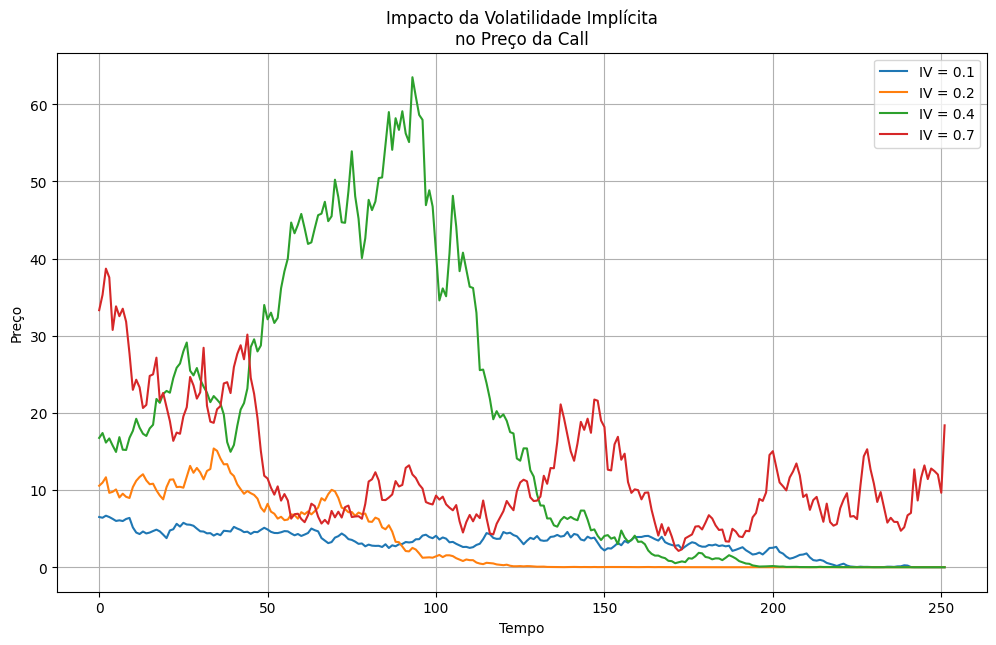

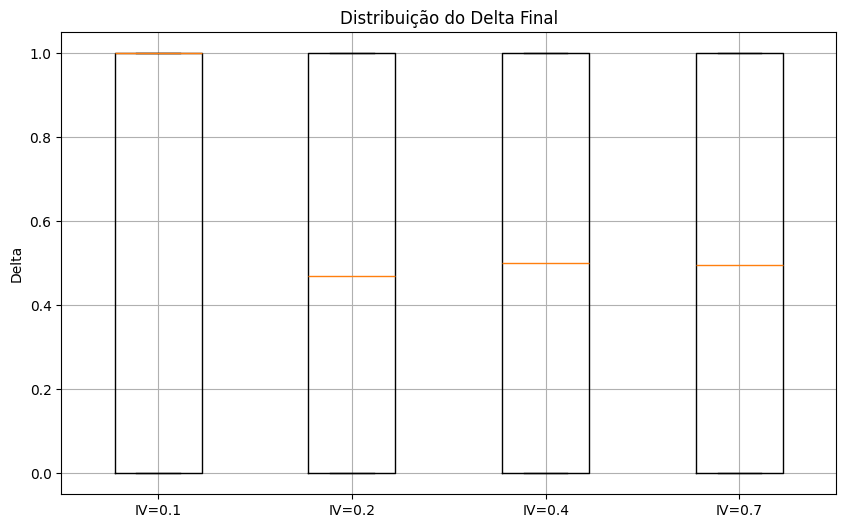


RESUMO DOS CENÁRIOS

               Scenario  Call Mean   Call Std  Delta Mean     Gamma Mean
0    IV=0.1_T=0.12_K=90  10.375782   3.783272    1.000000   0.000000e+00
1   IV=0.1_T=0.12_K=100   0.663054   1.025595    0.450007   2.620763e-03
2   IV=0.1_T=0.12_K=110   0.000000   0.000000    0.000000   0.000000e+00
3    IV=0.1_T=0.36_K=90  11.519945   5.041592    1.000000   0.000000e+00
4   IV=0.1_T=0.36_K=100   2.060558   3.242770    0.400000   0.000000e+00
5   IV=0.1_T=0.36_K=110   0.223806   0.975547    0.050000   0.000000e+00
6    IV=0.1_T=0.71_K=90   8.866502   7.481789    0.800000   0.000000e+00
7   IV=0.1_T=0.71_K=100   3.753923   6.284597    0.500000   0.000000e+00
8   IV=0.1_T=0.71_K=110   0.457639   1.221499    0.200000   4.621153e-85
9     IV=0.1_T=1.0_K=90  10.258396   9.450208    0.650000  3.677124e-181
10   IV=0.1_T=1.0_K=100   3.447341   4.756739    0.600000   1.920224e-32
11   IV=0.1_T=1.0_K=110   1.602932   5.086216    0.100000   0.000000e+00
12   IV=0.2_T=0.12_K=90  12.1

In [ ]:

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def black_scholes_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def delta_call(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    return norm.cdf(d1)


def gamma_call(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    return norm.pdf(d1)/(S*sigma*np.sqrt(T))


# ============================================================
# SIMULAÇÃO DE TRAJETÓRIA
# ============================================================

def simulate_path(
    S0,
    K,
    r,
    sigma,
    T_total,
    steps
):

    dt = T_total / steps

    S_path = [S0]
    C_path = []
    delta_path = []
    gamma_path = []

    for t in range(steps):

        epsilon = np.random.normal(
            0,
            sigma*np.sqrt(dt)
        )

        S_new = S_path[-1]*(1 + epsilon)

        S_path.append(S_new)

        T_remaining = max(
            T_total - (t+1)*dt,
            1e-6
        )

        C = black_scholes_call(
            S_new,
            K,
            T_remaining,
            r,
            sigma
        )

        delta = delta_call(
            S_new,
            K,
            T_remaining,
            r,
            sigma
        )

        gamma = gamma_call(
            S_new,
            K,
            T_remaining,
            r,
            sigma
        )

        C_path.append(C)
        delta_path.append(delta)
        gamma_path.append(gamma)

    return {
        "spot": np.array(S_path[1:]),
        "call": np.array(C_path),
        "delta": np.array(delta_path),
        "gamma": np.array(gamma_path)
    }


# ============================================================
# CONFIGURAÇÕES DO EXPERIMENTO
# ============================================================

np.random.seed(42)

S0 = 100
r = 0.05

steps = 252

# Diferentes maturidades
maturities = [
    30/252,
    90/252,
    180/252,
    1.0
]

# Diferentes IVs
vols = [
    0.10,
    0.20,
    0.40,
    0.70
]

# Diferentes moneynesses
strikes = [
    90,   # ITM
    100,  # ATM
    110   # OTM
]

# Número de trajetórias
n_paths = 20

results = {}

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for sigma in vols:

    for T_total in maturities:

        for K in strikes:

            key = f"IV={sigma}_T={round(T_total,2)}_K={K}"

            simulations = []

            for i in range(n_paths):

                sim = simulate_path(
                    S0=S0,
                    K=K,
                    r=r,
                    sigma=sigma,
                    T_total=T_total,
                    steps=steps
                )

                simulations.append(sim)

            results[key] = simulations


# ============================================================
# VISUALIZAÇÃO 1
# TRAJETÓRIAS DE PREÇO DAS CALLS
# ============================================================

fig, ax = plt.subplots(figsize=(12,7))

example_key = "IV=0.2_T=1.0_K=100"

for sim in results[example_key]:

    ax.plot(sim["call"], alpha=0.7)

ax.set_title(
    "Trajetórias da Call Europeia\nIV=20%, ATM, 1 ano"
)

ax.set_xlabel("Tempo")
ax.set_ylabel("Preço da opção")

ax.grid(True)

plt.show()


# ============================================================
# VISUALIZAÇÃO 2
# GAMMA AO LONGO DO TEMPO
# ============================================================

fig, ax = plt.subplots(figsize=(12,7))

for sim in results[example_key]:

    ax.plot(sim["gamma"], alpha=0.7)

ax.set_title(
    "Evolução do Gamma\nIV=20%, ATM, 1 ano"
)

ax.set_xlabel("Tempo")
ax.set_ylabel("Gamma")

ax.grid(True)

plt.show()


# ============================================================
# VISUALIZAÇÃO 3
# COMPARAÇÃO ENTRE IVs
# ============================================================

fig, ax = plt.subplots(figsize=(12,7))

for sigma in vols:

    sim = results[f"IV={sigma}_T=1.0_K=100"][0]

    ax.plot(
        sim["call"],
        label=f"IV = {sigma}"
    )

ax.set_title(
    "Impacto da Volatilidade Implícita\nno Preço da Call"
)

ax.set_xlabel("Tempo")
ax.set_ylabel("Preço")

ax.legend()
ax.grid(True)

plt.show()


# ============================================================
# VISUALIZAÇÃO 4
# DELTA FINAL DISTRIBUIÇÃO
# ============================================================

final_deltas = []

labels = []

for sigma in vols:

    deltas = []

    for sim in results[f"IV={sigma}_T=1.0_K=100"]:

        deltas.append(sim["delta"][-1])

    final_deltas.append(deltas)

    labels.append(f"IV={sigma}")

fig, ax = plt.subplots(figsize=(10,6))

ax.boxplot(
    final_deltas,
    tick_labels=labels
)

ax.set_title(
    "Distribuição do Delta Final"
)

ax.set_ylabel("Delta")

ax.grid(True)

plt.show()


# ============================================================
# TABELA RESUMO
# ============================================================

summary = []

for key in results:

    calls_final = []

    gammas_final = []

    deltas_final = []

    for sim in results[key]:

        calls_final.append(sim["call"][-1])
        gammas_final.append(sim["gamma"][-1])
        deltas_final.append(sim["delta"][-1])

    summary.append({
        "Scenario": key,
        "Call Mean": np.mean(calls_final),
        "Call Std": np.std(calls_final),
        "Delta Mean": np.mean(deltas_final),
        "Gamma Mean": np.mean(gammas_final)
    })

summary_df = pd.DataFrame(summary)

print("\n============================")
print("RESUMO DOS CENÁRIOS")
print("============================\n")

print(summary_df)




ESTADO INICIAL
Spot inicial      : 100.00
Strike            : 105.00
IV anual          : 20.00%
DTE               : 90 dias

Preço da Call     : 3.4305
Delta inicial     : 0.4211
Gamma inicial     : 0.032723

RESULTADOS

    Shock (%)   Spot  Call BS  Call Delta-Gamma  Spot Return (%)  \
0       -15.0   85.0   0.2486            0.7951            -15.0   
1       -14.0   86.0   0.3143            0.7417            -14.0   
2       -13.0   87.0   0.3932            0.7211            -13.0   
3       -12.0   88.0   0.4874            0.7332            -12.0   
4       -11.0   89.0   0.5985            0.7780            -11.0   
5       -10.0   90.0   0.7284            0.8555            -10.0   
6        -9.0   91.0   0.8790            0.9657             -9.0   
7        -8.0   92.0   1.0521            1.1087             -8.0   
8        -7.0   93.0   1.2494            1.2844             -7.0   
9        -6.0   94.0   1.4727            1.4928             -6.0   
10       -5.0   95.0   1.7235 

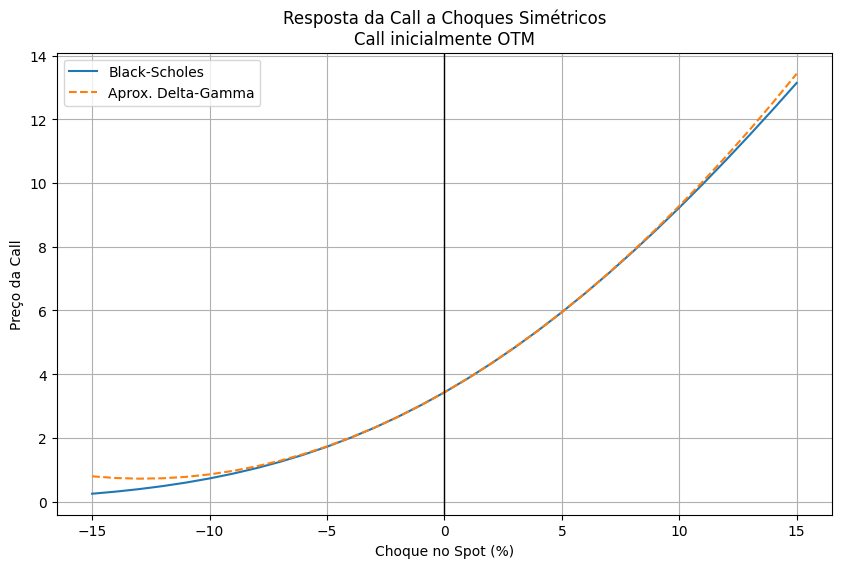

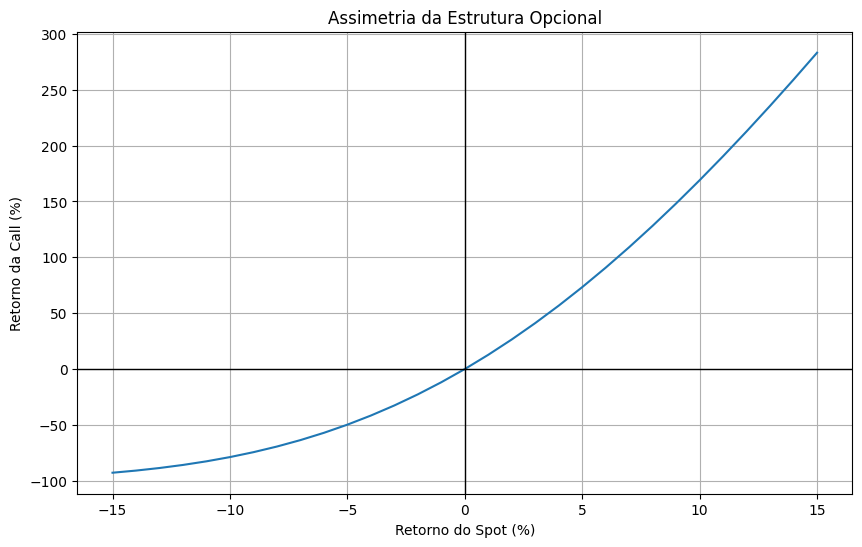

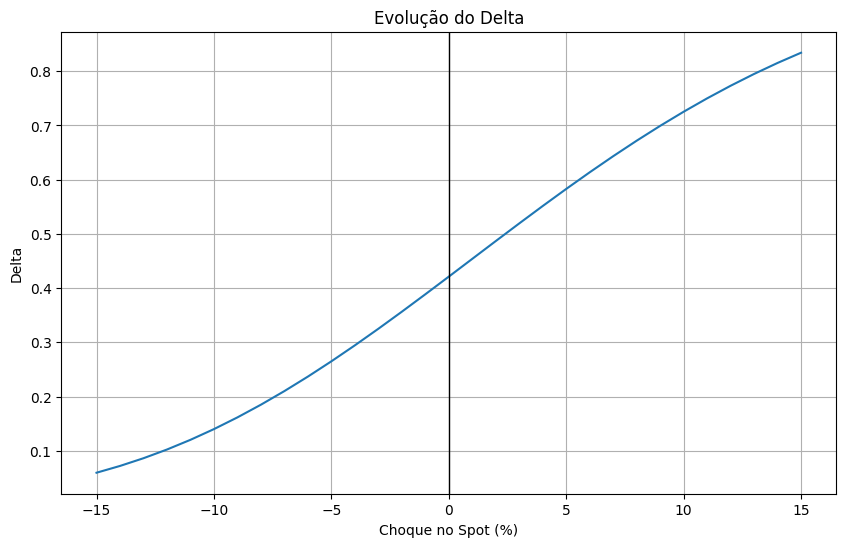

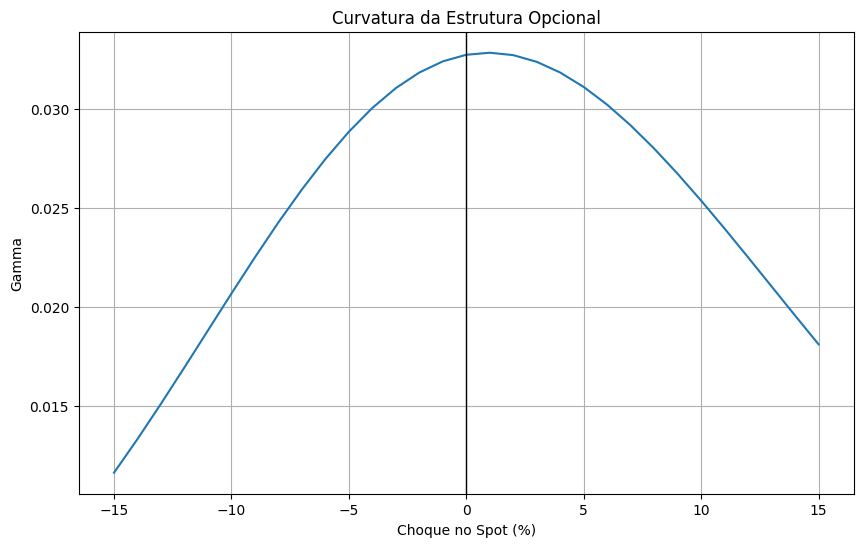

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def bs_delta(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

    return norm.pdf(d1)/(S*sigma*np.sqrt(T))


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

# ------------------------------------------------------------
# IDEIA DO CENÁRIO:
#
# Call inicialmente FORA DO DINHEIRO
# para observar:
#
# - convexidade
# - assimetria
# - resposta não linear
#
# Choques simétricos no spot:
#
# +1%, +2%, +3%, ...
# -1%, -2%, -3%, ...
#
# mantendo:
#
# - IV constante
# - taxa constante
# - maturidade fixa
#
# ============================================================

S0 = 100
K = 105                 # OTM leve
r = 0.05

sigma = 0.20            # IV anual fixa

DTE = 90                # 90 dias até vencimento
T = DTE/252

# ============================================================
# PREÇO INICIAL
# ============================================================

C0 = bs_call(S0, K, T, r, sigma)

delta0 = bs_delta(S0, K, T, r, sigma)

gamma0 = bs_gamma(S0, K, T, r, sigma)

print("\n==============================")
print("ESTADO INICIAL")
print("==============================")

print(f"Spot inicial      : {S0:.2f}")
print(f"Strike            : {K:.2f}")
print(f"IV anual          : {sigma:.2%}")
print(f"DTE               : {DTE} dias")

print(f"\nPreço da Call     : {C0:.4f}")
print(f"Delta inicial     : {delta0:.4f}")
print(f"Gamma inicial     : {gamma0:.6f}")

# ============================================================
# CHOQUES SIMÉTRICOS
# ============================================================

shocks = np.arange(-0.15, 0.16, 0.01)

results = []

for shock in shocks:

    # --------------------------------------------------------
    # Novo preço do spot
    # --------------------------------------------------------

    S_new = S0*(1 + shock)

    # --------------------------------------------------------
    # Novo preço da opção
    # --------------------------------------------------------

    C_new = bs_call(
        S_new,
        K,
        T,
        r,
        sigma
    )

    # --------------------------------------------------------
    # Aproximação Delta-Gamma
    # --------------------------------------------------------

    dS = S_new - S0

    dC_approx = (
        delta0*dS
        +
        0.5*gamma0*(dS**2)
    )

    C_approx = C0 + dC_approx

    # --------------------------------------------------------
    # Greeks atualizadas
    # --------------------------------------------------------

    delta_new = bs_delta(
        S_new,
        K,
        T,
        r,
        sigma
    )

    gamma_new = bs_gamma(
        S_new,
        K,
        T,
        r,
        sigma
    )

    # --------------------------------------------------------
    # Retornos
    # --------------------------------------------------------

    spot_return = (
        (S_new - S0)/S0
    )*100

    call_return = (
        (C_new - C0)/C0
    )*100

    results.append({

        "Shock (%)": shock*100,

        "Spot": S_new,

        "Call BS": C_new,

        "Call Delta-Gamma": C_approx,

        "Spot Return (%)": spot_return,

        "Call Return (%)": call_return,

        "Delta": delta_new,

        "Gamma": gamma_new
    })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print("\n==============================")
print("RESULTADOS")
print("==============================\n")

print(df.round(4))

# ============================================================
# GRÁFICO 1
# PREÇO DA CALL vs CHOQUE
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    df["Shock (%)"],
    df["Call BS"],
    label="Black-Scholes"
)

plt.plot(
    df["Shock (%)"],
    df["Call Delta-Gamma"],
    linestyle="--",
    label="Aprox. Delta-Gamma"
)

plt.axvline(0, color='black', linewidth=1)

plt.xlabel("Choque no Spot (%)")

plt.ylabel("Preço da Call")

plt.title(
    "Resposta da Call a Choques Simétricos\n"
    "Call inicialmente OTM"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 2
# RETORNO SPOT vs RETORNO CALL
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    df["Spot Return (%)"],
    df["Call Return (%)"]
)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel("Retorno do Spot (%)")

plt.ylabel("Retorno da Call (%)")

plt.title(
    "Assimetria da Estrutura Opcional"
)

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 3
# DELTA AO LONGO DOS CHOQUES
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    df["Shock (%)"],
    df["Delta"]
)

plt.axvline(0, color='black', linewidth=1)

plt.xlabel("Choque no Spot (%)")

plt.ylabel("Delta")

plt.title(
    "Evolução do Delta"
)

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 4
# GAMMA AO LONGO DOS CHOQUES
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    df["Shock (%)"],
    df["Gamma"]
)

plt.axvline(0, color='black', linewidth=1)

plt.xlabel("Choque no Spot (%)")

plt.ylabel("Gamma")

plt.title(
    "Curvatura da Estrutura Opcional"
)

plt.grid(True)

plt.show()


CENÁRIO: Deep ITM
Strike           : 85
Preço inicial    : 16.8174
Delta inicial    : 0.9417
Gamma inicial    : 0.009749

CENÁRIO: ITM
Strike           : 95
Preço inicial    : 8.6958
Delta inicial    : 0.7384
Gamma inicial    : 0.027226

CENÁRIO: ATM
Strike           : 100
Preço inicial    : 5.6607
Delta inicial    : 0.5828
Gamma inicial    : 0.032656

CENÁRIO: OTM
Strike           : 105
Preço inicial    : 3.4305
Delta inicial    : 0.4211
Gamma inicial    : 0.032723

CENÁRIO: Deep OTM
Strike           : 115
Preço inicial    : 1.0177
Delta inicial    : 0.1685
Gamma inicial    : 0.021051


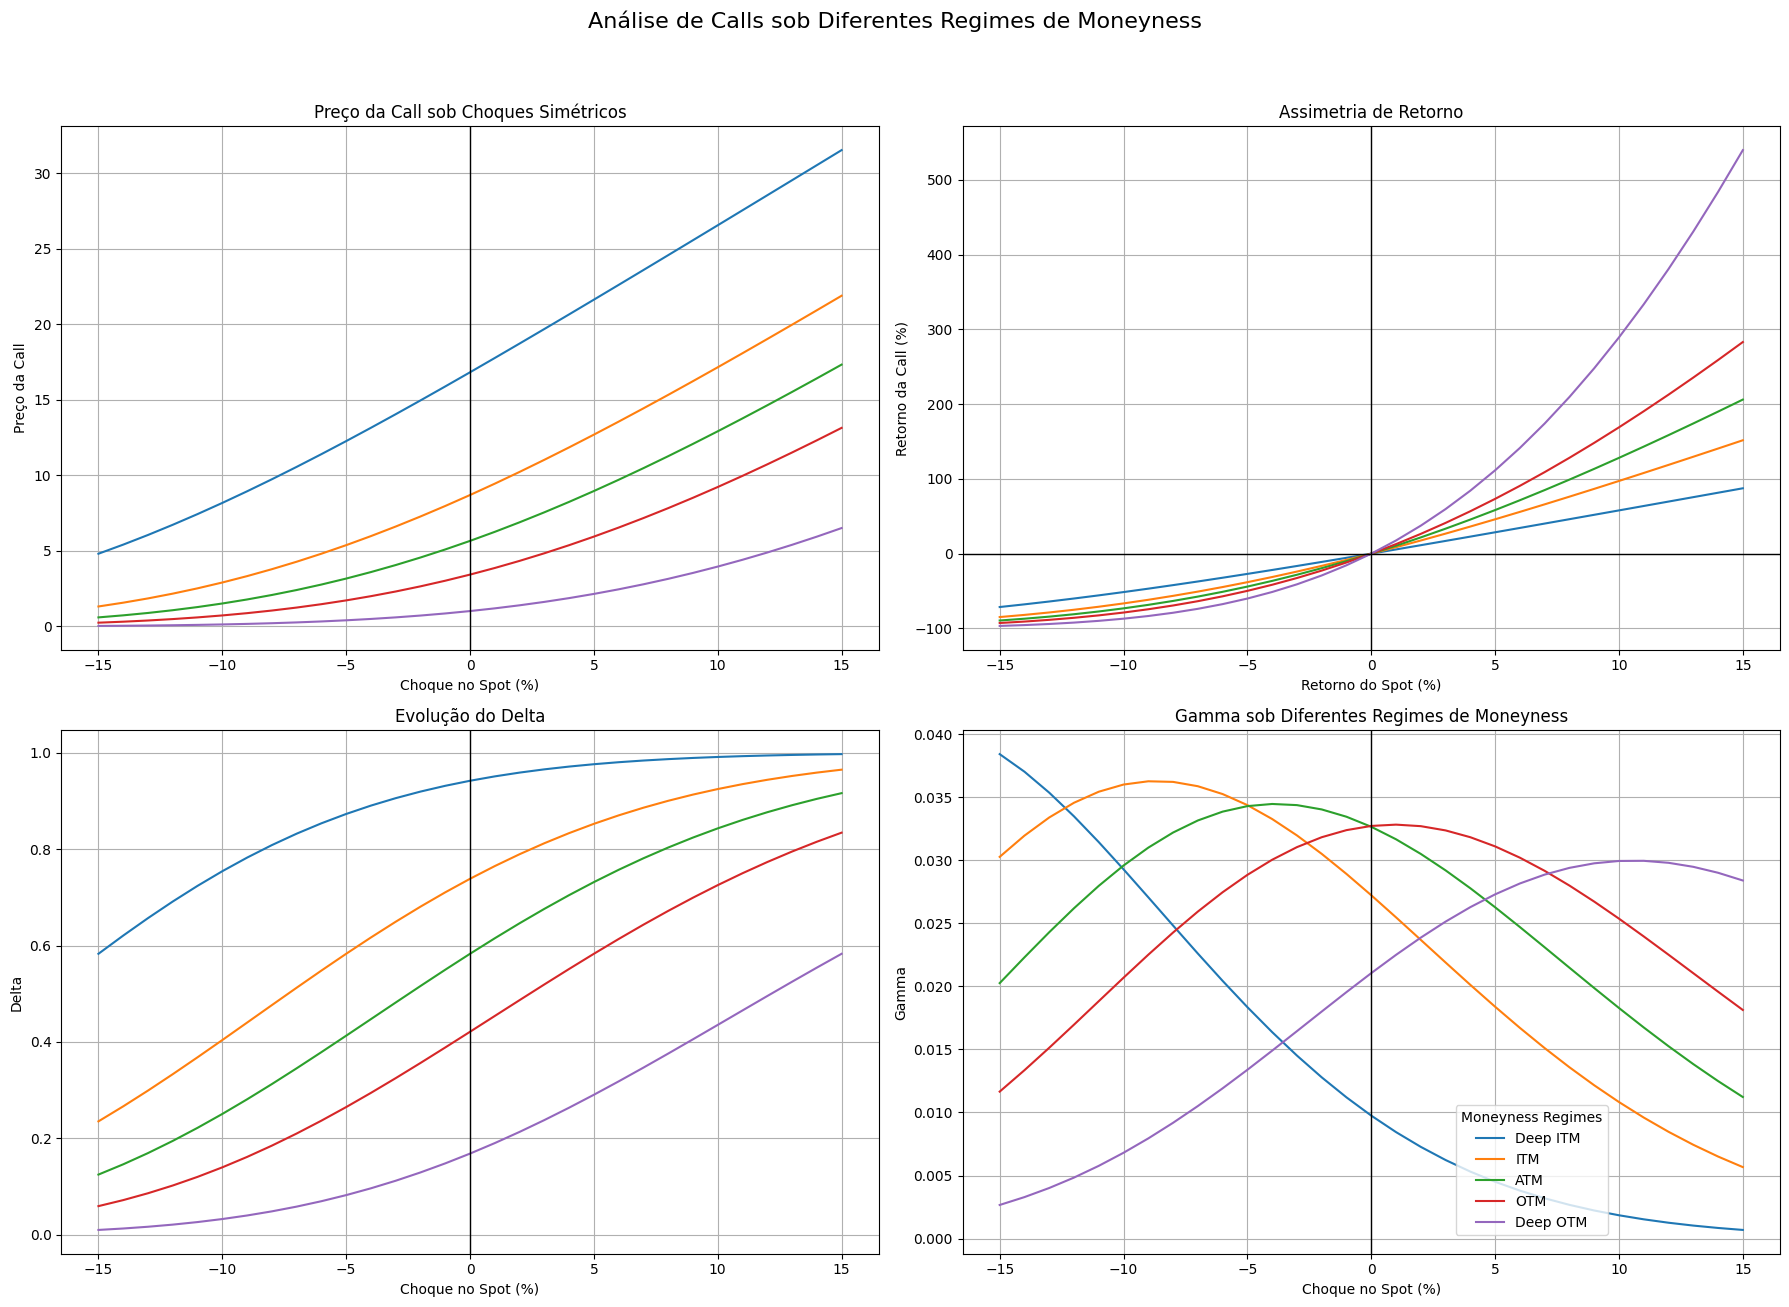


RESUMO DOS CENÁRIOS

  Moneyness  Strike  Preço Inicial  Delta Inicial  Gamma Inicial
0  Deep ITM      85        16.8174         0.9417       0.009749
1       ITM      95         8.6958         0.7384       0.027226
2       ATM     100         5.6607         0.5828       0.032656
3       OTM     105         3.4305         0.4211       0.032723
4  Deep OTM     115         1.0177         0.1685       0.021051


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def bs_delta(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    return norm.pdf(d1)/(S*sigma*np.sqrt(T))


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

S0 = 100
r = 0.05

sigma = 0.20        # IV anual fixa

DTE = 90
T = DTE/252

# ------------------------------------------------------------
# Moneyness
#
# ITM  -> K < S0
# ATM  -> K = S0
# OTM  -> K > S0
# ------------------------------------------------------------

strikes = {

    "Deep ITM": 85,
    "ITM": 95,
    "ATM": 100,
    "OTM": 105,
    "Deep OTM": 115
}

# ============================================================
# CHOQUES SIMÉTRICOS
# ============================================================

shocks = np.arange(-0.15, 0.16, 0.01)

# ============================================================
# ARMAZENAMENTO
# ============================================================

all_results = {}

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for label, K in strikes.items():

    C0 = bs_call(S0, K, T, r, sigma)

    delta0 = bs_delta(S0, K, T, r, sigma)

    gamma0 = bs_gamma(S0, K, T, r, sigma)

    results = []

    for shock in shocks:

        # ----------------------------------------------------
        # Novo spot
        # ----------------------------------------------------

        S_new = S0*(1 + shock)

        # ----------------------------------------------------
        # Black-Scholes completo
        # ----------------------------------------------------

        C_new = bs_call(
            S_new,
            K,
            T,
            r,
            sigma
        )

        # ----------------------------------------------------
        # Aproximação Delta-Gamma
        # ----------------------------------------------------

        dS = S_new - S0

        dC_approx = (
            delta0*dS
            +
            0.5*gamma0*(dS**2)
        )

        C_approx = C0 + dC_approx

        # ----------------------------------------------------
        # Greeks atualizadas
        # ----------------------------------------------------

        delta_new = bs_delta(
            S_new,
            K,
            T,
            r,
            sigma
        )

        gamma_new = bs_gamma(
            S_new,
            K,
            T,
            r,
            sigma
        )

        # ----------------------------------------------------
        # Retornos
        # ----------------------------------------------------

        spot_return = (
            (S_new - S0)/S0
        )*100

        call_return = (
            (C_new - C0)/C0
        )*100

        results.append({

            "Shock (%)": shock*100,

            "Spot": S_new,

            "Call BS": C_new,

            "Call Delta-Gamma": C_approx,

            "Spot Return (%)": spot_return,

            "Call Return (%)": call_return,

            "Delta": delta_new,

            "Gamma": gamma_new
        })

    all_results[label] = pd.DataFrame(results)

    print("\n========================================")
    print(f"CENÁRIO: {label}")
    print("========================================")

    print(f"Strike           : {K}")
    print(f"Preço inicial    : {C0:.4f}")
    print(f"Delta inicial    : {delta0:.4f}")
    print(f"Gamma inicial    : {gamma0:.6f}")

# ============================================================
# GRÁFICO 1-4 COMBINADOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Análise de Calls sob Diferentes Regimes de Moneyness", fontsize=16)

# Plot 1: CALL vs CHOQUE
for label in strikes.keys():
    df = all_results[label]
    axes[0, 0].plot(df["Shock (%)"], df["Call BS"], label=label)
axes[0, 0].axvline(0, color='black', linewidth=1)
axes[0, 0].set_xlabel("Choque no Spot (%)")
axes[0, 0].set_ylabel("Preço da Call")
axes[0, 0].set_title("Preço da Call sob Choques Simétricos")
axes[0, 0].grid(True)

# Plot 2: RETORNO DA CALL
for label in strikes.keys():
    df = all_results[label]
    axes[0, 1].plot(df["Spot Return (%)"], df["Call Return (%)"], label=label)
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].axvline(0, color='black', linewidth=1)
axes[0, 1].set_xlabel("Retorno do Spot (%)")
axes[0, 1].set_ylabel("Retorno da Call (%)")
axes[0, 1].set_title("Assimetria de Retorno")
axes[0, 1].grid(True)

# Plot 3: DELTA
for label in strikes.keys():
    df = all_results[label]
    axes[1, 0].plot(df["Shock (%)"], df["Delta"], label=label)
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_xlabel("Choque no Spot (%)")
axes[1, 0].set_ylabel("Delta")
axes[1, 0].set_title("Evolução do Delta")
axes[1, 0].grid(True)

# Plot 4: GAMMA
for label in strikes.keys():
    df = all_results[label]
    axes[1, 1].plot(df["Shock (%)"], df["Gamma"], label=label)
axes[1, 1].axvline(0, color='black', linewidth=1)
axes[1, 1].set_xlabel("Choque no Spot (%)")
axes[1, 1].set_ylabel("Gamma")
axes[1, 1].set_title("Gamma sob Diferentes Regimes de Moneyness")
axes[1, 1].grid(True)

# Adicionar uma única legenda para toda a figura
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.9, 0.1), title="Moneyness Regimes")

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Ajustar layout para não sobrepor o título
plt.show()

# ============================================================
# TABELA RESUMO
# ============================================================

summary = []

for label, K in strikes.items():

    C0 = bs_call(S0, K, T, r, sigma)

    delta0 = bs_delta(S0, K, T, r, sigma)

    gamma0 = bs_gamma(S0, K, T, r, sigma)

    summary.append({

        "Moneyness": label,

        "Strike": K,

        "Preço Inicial": round(C0,4),

        "Delta Inicial": round(delta0,4),

        "Gamma Inicial": round(gamma0,6)
    })

summary_df = pd.DataFrame(summary)

print("\n========================================")
print("RESUMO DOS CENÁRIOS")
print("========================================\n")

print(summary_df)


AMOSTRA DOS RESULTADOS

     IV  Strike  Moneyness  Days Passed  Remaining DTE  Spot  Spot Return (%)  \
0  0.15     102       1.02            5             85  85.0            -15.0   
1  0.15     102       1.02            5             85  85.5            -14.5   
2  0.15     102       1.02            5             85  86.0            -14.0   
3  0.15     102       1.02            5             85  86.5            -13.5   
4  0.15     102       1.02            5             85  87.0            -13.0   

   Initial Call  New Call  Call Return (%)  Convexity Ratio  Delta Initial  \
0      3.481961  0.089023       -97.443311         6.496221       0.509222   
1      3.481961  0.106150       -96.951440         6.686306       0.509222   
2      3.481961  0.125984       -96.381811         6.884415       0.509222   
3      3.481961  0.148845       -95.725248         7.090759       0.509222   
4      3.481961  0.175073       -94.971986         7.305537       0.509222   

   Gamma Initial  T

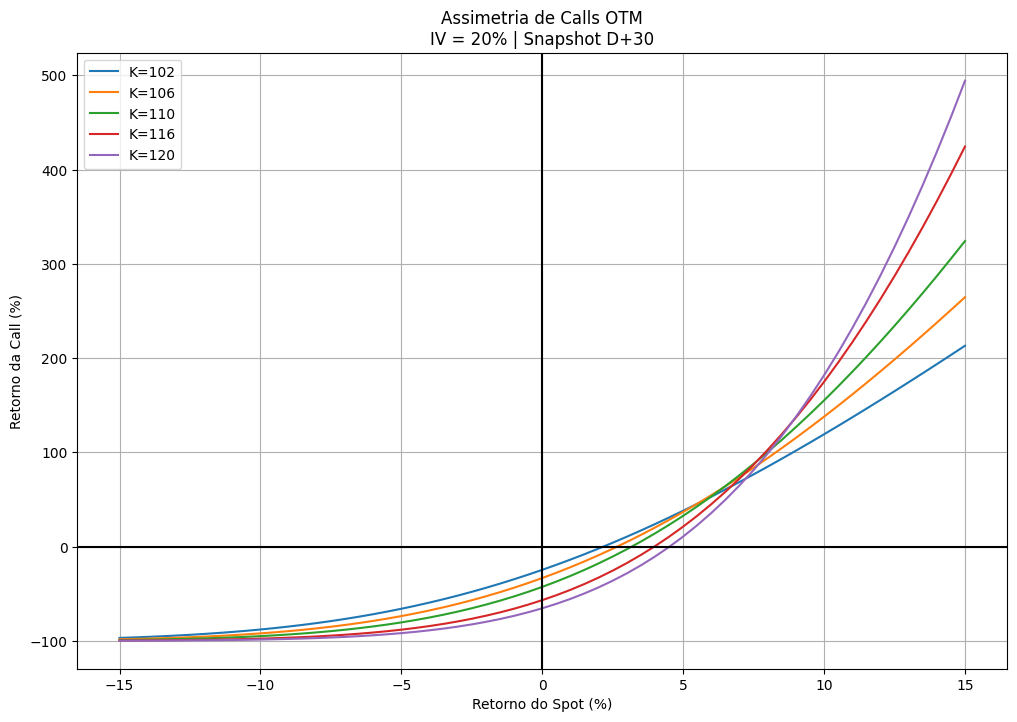

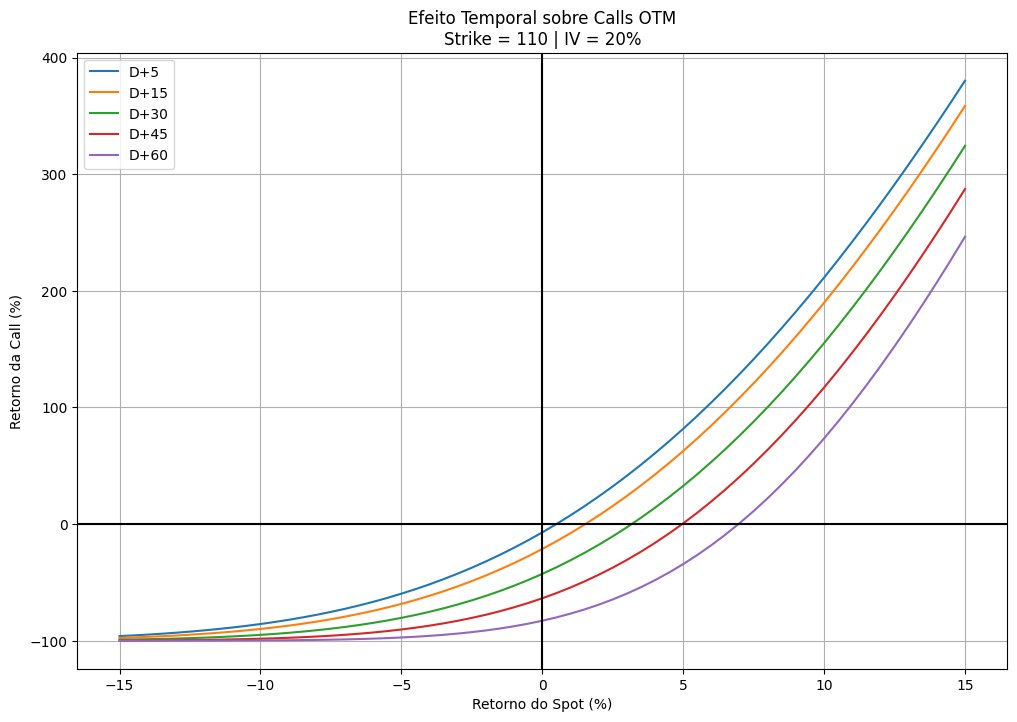

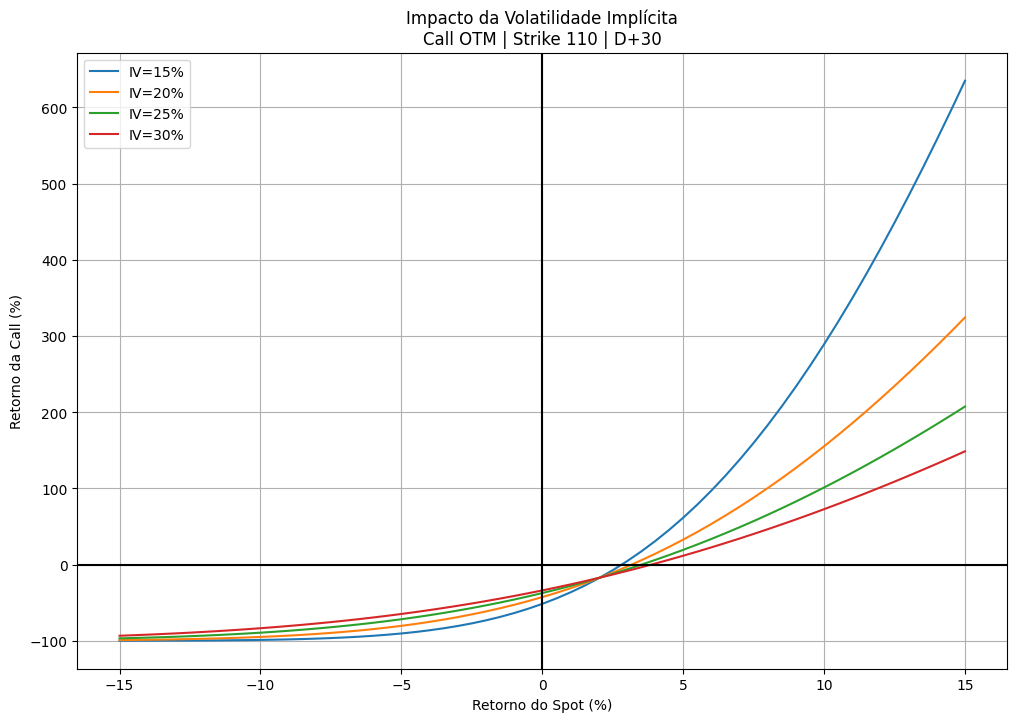

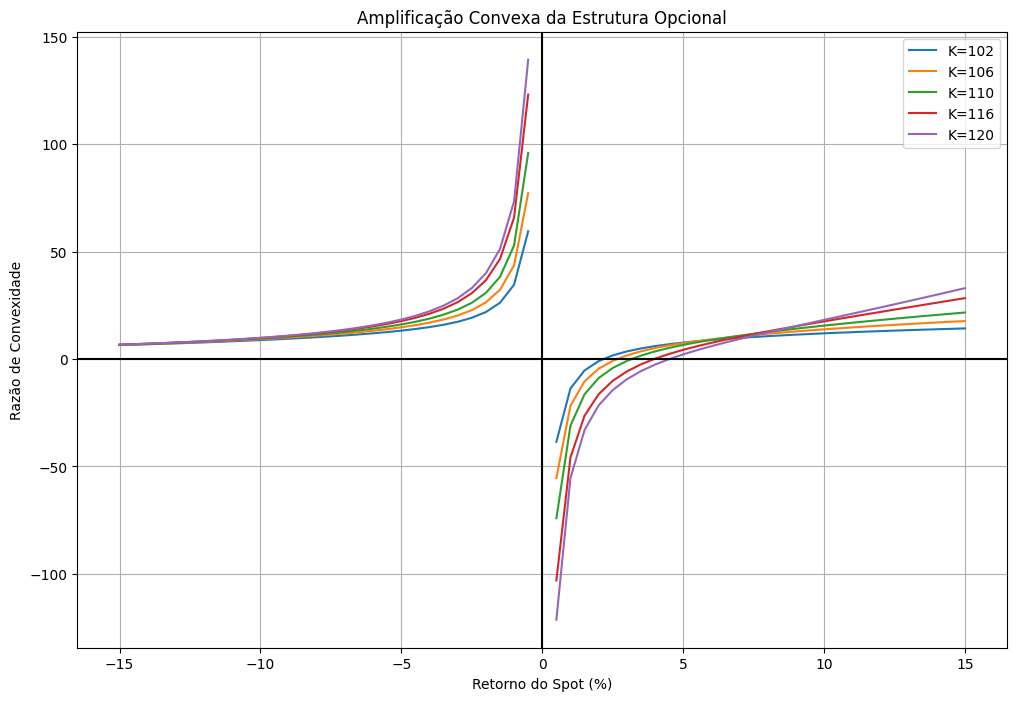


RESUMO ESTATÍSTICO

  Strike    IV Days Passed Initial Call  New Call Call Return (%)              \
                                   mean      mean            mean         std   
0    102  0.15           5     3.481961  4.887458       40.365082  132.330738   
1    102  0.15          10     3.481961  4.772793       37.071972  131.504001   
2    102  0.15          15     3.481961  4.657591       33.763425  130.664405   
3    102  0.15          20     3.481961  4.541852       30.439477  129.812716   
4    102  0.15          30     3.481961  4.308785       23.745919  128.078212   

  Convexity Ratio Theta Daily Gamma Initial Delta Initial  
             mean        mean          mean          mean  
0       14.351468   -0.029275      0.044492      0.509222  
1       14.212076   -0.029275      0.044492      0.509222  
2       14.066158   -0.029275      0.044492      0.509222  
3       13.912991   -0.029275      0.044492      0.509222  
4       13.581309   -0.029275      0.044492      0.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    return (
        S*norm.cdf(d1)
        - K*np.exp(-r*T)*norm.cdf(d2)
    )


def bs_delta(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return (
        norm.pdf(d1)
        / (S*sigma*np.sqrt(T))
    )


def bs_theta_call(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    theta = (
        -(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
        - r*K*np.exp(-r*T)*norm.cdf(d2)
    )

    # theta diário
    return theta/252


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

S0 = 100

r = 0.05

# ------------------------------------------------------------
# Volatilidades implícitas anuais
# ------------------------------------------------------------

ivs = [0.15, 0.20, 0.25, 0.30]

# ------------------------------------------------------------
# Calls OTM moderadas
# ------------------------------------------------------------

strikes = [
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120
]

# ------------------------------------------------------------
# Opção nasce com 90 DTE
# ------------------------------------------------------------

initial_dte = 90

# ------------------------------------------------------------
# Snapshots observados
# ------------------------------------------------------------

snapshots = [
    5,
    10,
    15,
    20,
    30,
    45,
    60
]

# ------------------------------------------------------------
# Choques simétricos no spot
# ------------------------------------------------------------

spot_returns = np.linspace(
    -0.15,
    0.15,
    61
)

# ============================================================
# DATASET
# ============================================================

results = []

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for sigma in ivs:

    for K in strikes:

        # ----------------------------------------------------
        # Estado inicial
        # ----------------------------------------------------

        T0 = initial_dte/252

        C0 = bs_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        delta0 = bs_delta(
            S0,
            K,
            T0,
            r,
            sigma
        )

        gamma0 = bs_gamma(
            S0,
            K,
            T0,
            r,
            sigma
        )

        theta0 = bs_theta_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        # ----------------------------------------------------
        # Evolução temporal
        # ----------------------------------------------------

        for days_passed in snapshots:

            remaining_dte = (
                initial_dte
                - days_passed
            )

            T_remaining = (
                remaining_dte/252
            )

            # ------------------------------------------------
            # Choques no spot
            # ------------------------------------------------

            for ret in spot_returns:

                S_new = S0*(1 + ret)

                # --------------------------------------------
                # Novo preço da opção
                # --------------------------------------------

                C_new = bs_call(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                # --------------------------------------------
                # Greeks atualizadas
                # --------------------------------------------

                delta_new = bs_delta(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                gamma_new = bs_gamma(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                # --------------------------------------------
                # Retornos
                # --------------------------------------------

                spot_return_pct = ret*100

                call_return_pct = (
                    (C_new - C0)/C0
                )*100

                # --------------------------------------------
                # Razão de convexidade
                # --------------------------------------------

                if abs(spot_return_pct) > 1e-8:

                    convexity_ratio = (
                        call_return_pct
                        /
                        spot_return_pct
                    )

                else:

                    convexity_ratio = np.nan

                # --------------------------------------------
                # Armazenamento
                # --------------------------------------------

                results.append({

                    "IV": sigma,

                    "Strike": K,

                    "Moneyness":
                        round(K/S0,3),

                    "Days Passed":
                        days_passed,

                    "Remaining DTE":
                        remaining_dte,

                    "Spot":
                        S_new,

                    "Spot Return (%)":
                        spot_return_pct,

                    "Initial Call":
                        C0,

                    "New Call":
                        C_new,

                    "Call Return (%)":
                        call_return_pct,

                    "Convexity Ratio":
                        convexity_ratio,

                    "Delta Initial":
                        delta0,

                    "Gamma Initial":
                        gamma0,

                    "Theta Daily":
                        theta0,

                    "Delta New":
                        delta_new,

                    "Gamma New":
                        gamma_new
                })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print("\n======================================")
print("AMOSTRA DOS RESULTADOS")
print("======================================\n")

print(df.head())

# ============================================================
# GRÁFICO 1
# ASSIMETRIA OTM
# ============================================================

plt.figure(figsize=(12,8))

example_strikes = [
    102,
    106,
    110,
    116,
    120
]

for K in example_strikes:

    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]

    plt.plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"K={K}"
    )

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.xlabel("Retorno do Spot (%)")

plt.ylabel("Retorno da Call (%)")

plt.title(
    "Assimetria de Calls OTM\n"
    "IV = 20% | Snapshot D+30"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 2
# IMPACTO DO TEMPO
# ============================================================

plt.figure(figsize=(12,8))

example_days = [
    5,
    15,
    30,
    45,
    60
]

for d in example_days:

    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == d)
        &
        (df["IV"] == 0.20)
    ]

    plt.plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"D+{d}"
    )

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.xlabel("Retorno do Spot (%)")

plt.ylabel("Retorno da Call (%)")

plt.title(
    "Efeito Temporal sobre Calls OTM\n"
    "Strike = 110 | IV = 20%"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 3
# IMPACTO DA IV
# ============================================================

plt.figure(figsize=(12,8))

example_ivs = [
    0.15,
    0.20,
    0.25,
    0.30
]

for sigma in example_ivs:

    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == sigma)
    ]

    plt.plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"IV={sigma:.0%}"
    )

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.xlabel("Retorno do Spot (%)")

plt.ylabel("Retorno da Call (%)")

plt.title(
    "Impacto da Volatilidade Implícita\n"
    "Call OTM | Strike 110 | D+30"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# GRÁFICO 4
# CONVEXIDADE
# ============================================================

plt.figure(figsize=(12,8))

for K in example_strikes:

    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]

    plt.plot(
        subset["Spot Return (%)"],
        subset["Convexity Ratio"],
        label=f"K={K}"
    )

plt.axhline(0, color='black')
plt.axvline(0, color='black')

plt.xlabel("Retorno do Spot (%)")

plt.ylabel("Razão de Convexidade")

plt.title(
    "Amplificação Convexa da Estrutura Opcional"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# TABELA RESUMO
# ============================================================

summary = df.groupby([
    "Strike",
    "IV",
    "Days Passed"
]).agg({

    "Initial Call": "mean",

    "New Call": "mean",

    "Call Return (%)": ["mean", "std"],

    "Convexity Ratio": "mean",

    "Theta Daily": "mean",

    "Gamma Initial": "mean",

    "Delta Initial": "mean"

}).reset_index()

print("\n======================================")
print("RESUMO ESTATÍSTICO")
print("======================================\n")

print(summary.head())


AMOSTRA DOS RESULTADOS

     IV  Strike  Moneyness  Days Passed  Remaining DTE  Spot  Spot Return (%)  \
0  0.15     102       1.02            5             85  85.0            -15.0   
1  0.15     102       1.02            5             85  85.5            -14.5   
2  0.15     102       1.02            5             85  86.0            -14.0   
3  0.15     102       1.02            5             85  86.5            -13.5   
4  0.15     102       1.02            5             85  87.0            -13.0   

   Initial Call  New Call  Call Return (%)  Convexity Ratio  Delta Initial  \
0      3.481961  0.089023       -97.443311         6.496221       0.509222   
1      3.481961  0.106150       -96.951440         6.686306       0.509222   
2      3.481961  0.125984       -96.381811         6.884415       0.509222   
3      3.481961  0.148845       -95.725248         7.090759       0.509222   
4      3.481961  0.175073       -94.971986         7.305537       0.509222   

   Gamma Initial  T

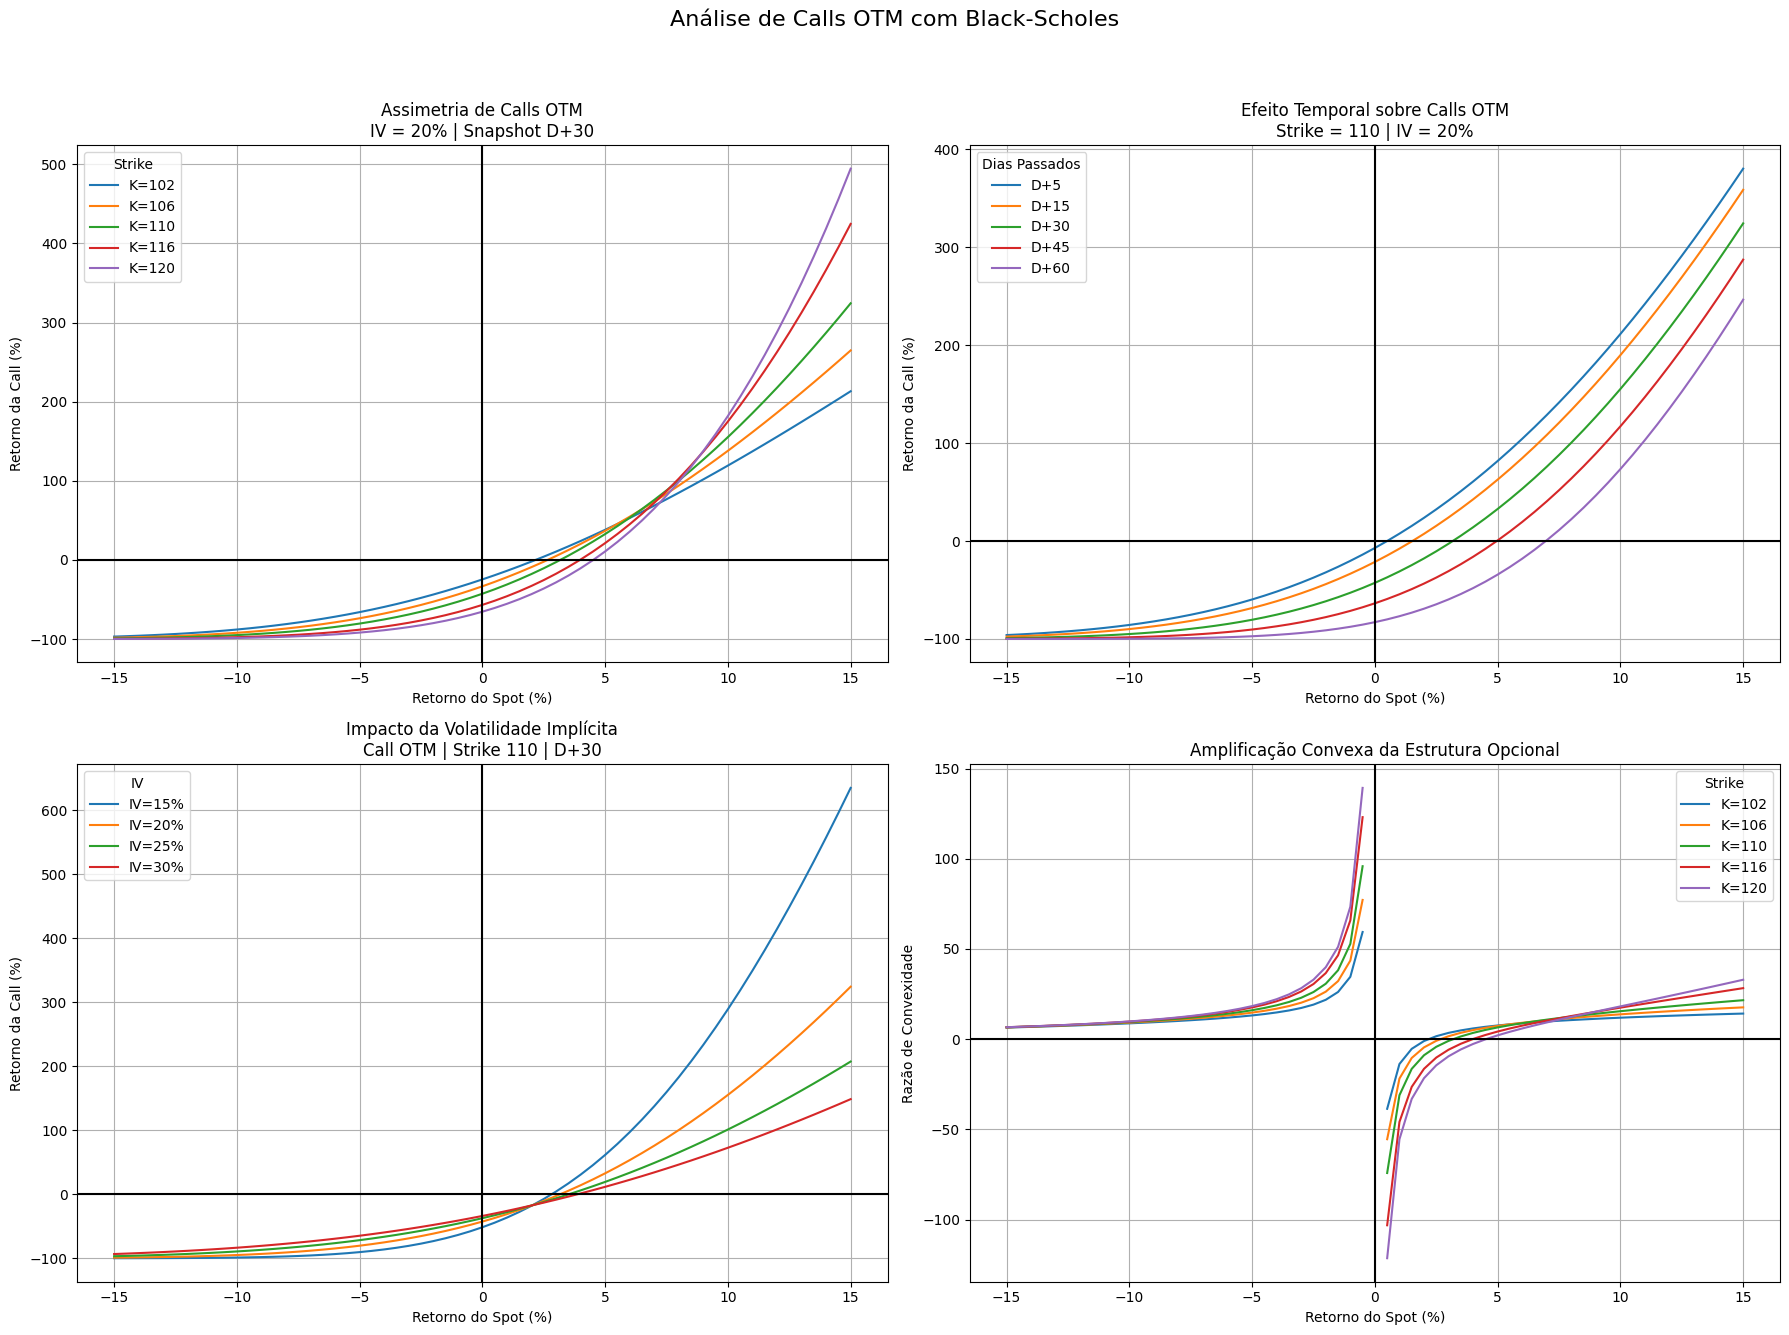


RESUMO ESTATÍSTICO

  Strike    IV Days Passed Initial Call  New Call Call Return (%)              \
                                   mean      mean            mean         std   
0    102  0.15           5     3.481961  4.887458       40.365082  132.330738   
1    102  0.15          10     3.481961  4.772793       37.071972  131.504001   
2    102  0.15          15     3.481961  4.657591       33.763425  130.664405   
3    102  0.15          20     3.481961  4.541852       30.439477  129.812716   
4    102  0.15          30     3.481961  4.308785       23.745919  128.078212   

  Convexity Ratio Theta Daily Gamma Initial Delta Initial  
             mean        mean          mean          mean  
0       14.351468   -0.029275      0.044492      0.509222  
1       14.212076   -0.029275      0.044492      0.509222  
2       14.066158   -0.029275      0.044492      0.509222  
3       13.912991   -0.029275      0.044492      0.509222  
4       13.581309   -0.029275      0.044492      0.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    return (
        S*norm.cdf(d1)
        - K*np.exp(-r*T)*norm.cdf(d2)
    )


def bs_delta(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return (
        norm.pdf(d1)
        / (S*sigma*np.sqrt(T))
    )


def bs_theta_call(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    theta = (
        -(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T))
        - r*K*np.exp(-r*T)*norm.cdf(d2)
    )

    # theta diário
    return theta/252


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

S0 = 100

r = 0.05

# ------------------------------------------------------------
# Volatilidades implícitas anuais
# ------------------------------------------------------------

ivs = [0.15, 0.20, 0.25, 0.30]

# ------------------------------------------------------------
# Calls OTM moderadas
# ------------------------------------------------------------

strikes = [
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120
]

# ------------------------------------------------------------
# Opção nasce com 90 DTE
# ------------------------------------------------------------

initial_dte = 90

# ------------------------------------------------------------
# Snapshots observados
# ------------------------------------------------------------

snapshots = [
    5,
    10,
    15,
    20,
    30,
    45,
    60
]

# ------------------------------------------------------------
# Choques simétricos no spot
# ------------------------------------------------------------

spot_returns = np.linspace(
    -0.15,
    0.15,
    61
)

# ============================================================
# DATASET
# ============================================================

results = []

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for sigma in ivs:

    for K in strikes:

        # ----------------------------------------------------
        # Estado inicial
        # ----------------------------------------------------

        T0 = initial_dte/252

        C0 = bs_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        delta0 = bs_delta(
            S0,
            K,
            T0,
            r,
            sigma
        )

        gamma0 = bs_gamma(
            S0,
            K,
            T0,
            r,
            sigma
        )

        theta0 = bs_theta_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        # ----------------------------------------------------
        # Evolução temporal
        # ----------------------------------------------------

        for days_passed in snapshots:

            remaining_dte = (
                initial_dte
                - days_passed
            )

            T_remaining = (
                remaining_dte/252
            )

            # ------------------------------------------------
            # Choques no spot
            # ------------------------------------------------

            for ret in spot_returns:

                S_new = S0*(1 + ret)

                # --------------------------------------------
                # Novo preço da opção
                # --------------------------------------------

                C_new = bs_call(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                # --------------------------------------------
                # Greeks atualizadas
                # --------------------------------------------

                delta_new = bs_delta(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                gamma_new = bs_gamma(
                    S_new,
                    K,
                    T_remaining,
                    r,
                    sigma
                )

                # --------------------------------------------
                # Retornos
                # --------------------------------------------

                spot_return_pct = ret*100

                call_return_pct = (
                    (C_new - C0)/C0
                )*100

                # --------------------------------------------
                # Razão de convexidade
                # --------------------------------------------

                if abs(spot_return_pct) > 1e-8:

                    convexity_ratio = (
                        call_return_pct
                        /
                        spot_return_pct
                    )

                else:

                    convexity_ratio = np.nan

                # --------------------------------------------
                # Armazenamento
                # --------------------------------------------

                results.append({

                    "IV": sigma,

                    "Strike": K,

                    "Moneyness":
                        round(K/S0,3),

                    "Days Passed":
                        days_passed,

                    "Remaining DTE":
                        remaining_dte,

                    "Spot":
                        S_new,

                    "Spot Return (%)":
                        spot_return_pct,

                    "Initial Call":
                        C0,

                    "New Call":
                        C_new,

                    "Call Return (%)":
                        call_return_pct,

                    "Convexity Ratio":
                        convexity_ratio,

                    "Delta Initial":
                        delta0,

                    "Gamma Initial":
                        gamma0,

                    "Theta Daily":
                        theta0,

                    "Delta New":
                        delta_new,

                    "Gamma New":
                        gamma_new
                })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print("\n======================================")
print("AMOSTRA DOS RESULTADOS")
print("======================================\n")

print(df.head())

# ============================================================
# GRÁFICO 1-4 COMBINADOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Análise de Calls OTM com Black-Scholes", fontsize=16)

example_strikes = [
    102,
    106,
    110,
    116,
    120
]

example_days = [
    5,
    15,
    30,
    45,
    60
]

example_ivs = [
    0.15,
    0.20,
    0.25,
    0.30
]

# Plot 1: ASSIMETRIA OTM
for K in example_strikes:
    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]
    axes[0, 0].plot(subset["Spot Return (%)"], subset["Call Return (%)"], label=f"K={K}")
axes[0, 0].axhline(0, color='black')
axes[0, 0].axvline(0, color='black')
axes[0, 0].set_xlabel("Retorno do Spot (%)")
axes[0, 0].set_ylabel("Retorno da Call (%)")
axes[0, 0].set_title("Assimetria de Calls OTM\nIV = 20% | Snapshot D+30")
axes[0, 0].grid(True)
axes[0, 0].legend(title="Strike")

# Plot 2: IMPACTO DO TEMPO
for d in example_days:
    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == d)
        &
        (df["IV"] == 0.20)
    ]
    axes[0, 1].plot(subset["Spot Return (%)"], subset["Call Return (%)"], label=f"D+{d}")
axes[0, 1].axhline(0, color='black')
axes[0, 1].axvline(0, color='black')
axes[0, 1].set_xlabel("Retorno do Spot (%)")
axes[0, 1].set_ylabel("Retorno da Call (%)")
axes[0, 1].set_title("Efeito Temporal sobre Calls OTM\nStrike = 110 | IV = 20%")
axes[0, 1].grid(True)
axes[0, 1].legend(title="Dias Passados")

# Plot 3: IMPACTO DA IV
for sigma_val in example_ivs:
    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == sigma_val)
    ]
    axes[1, 0].plot(subset["Spot Return (%)"], subset["Call Return (%)"], label=f"IV={sigma_val:.0%}")
axes[1, 0].axhline(0, color='black')
axes[1, 0].axvline(0, color='black')
axes[1, 0].set_xlabel("Retorno do Spot (%)")
axes[1, 0].set_ylabel("Retorno da Call (%)")
axes[1, 0].set_title("Impacto da Volatilidade Implícita\nCall OTM | Strike 110 | D+30")
axes[1, 0].grid(True)
axes[1, 0].legend(title="IV")

# Plot 4: CONVEXIDADE
for K in example_strikes:
    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]
    axes[1, 1].plot(subset["Spot Return (%)"], subset["Convexity Ratio"], label=f"K={K}")
axes[1, 1].axhline(0, color='black')
axes[1, 1].axvline(0, color='black')
axes[1, 1].set_xlabel("Retorno do Spot (%)")
axes[1, 1].set_ylabel("Razão de Convexidade")
axes[1, 1].set_title("Amplificação Convexa da Estrutura Opcional")
axes[1, 1].grid(True)
axes[1, 1].legend(title="Strike")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para não sobrepor o título
plt.show()

# ============================================================
# TABELA RESUMO
# ============================================================

summary = df.groupby([
    "Strike",
    "IV",
    "Days Passed"
]).agg({

    "Initial Call": "mean",

    "New Call": "mean",

    "Call Return (%)": ["mean", "std"],

    "Convexity Ratio": "mean",

    "Theta Daily": "mean",

    "Gamma Initial": "mean",

    "Delta Initial": "mean"

}).reset_index()

print("\n======================================")
print("RESUMO ESTATÍSTICO")
print("======================================\n")

print(summary.head())

# Cenário II


AMOSTRA DOS RESULTADOS

     IV  Strike  Moneyness  Days Passed  Remaining DTE  Spot  Spot Return (%)  \
0  0.15     102       1.02            5             85  85.0            -15.0   
1  0.15     102       1.02            5             85  85.5            -14.5   
2  0.15     102       1.02            5             85  86.0            -14.0   
3  0.15     102       1.02            5             85  86.5            -13.5   
4  0.15     102       1.02            5             85  87.0            -13.0   

   Initial Call   DG Call  Call Return (%)  Convexity Ratio     Delta  \
0      3.481961  0.848979       -75.617797         5.041186  0.509222   
1      3.481961  0.775462       -77.729174         5.360633  0.509222   
2      3.481961  0.713067       -79.521106         5.680079  0.509222   
3      3.481961  0.661796       -80.993591         5.999525  0.509222   
4      3.481961  0.621647       -82.146630         6.318972  0.509222   

      Gamma  Theta Daily  
0  0.044492    -0.0292

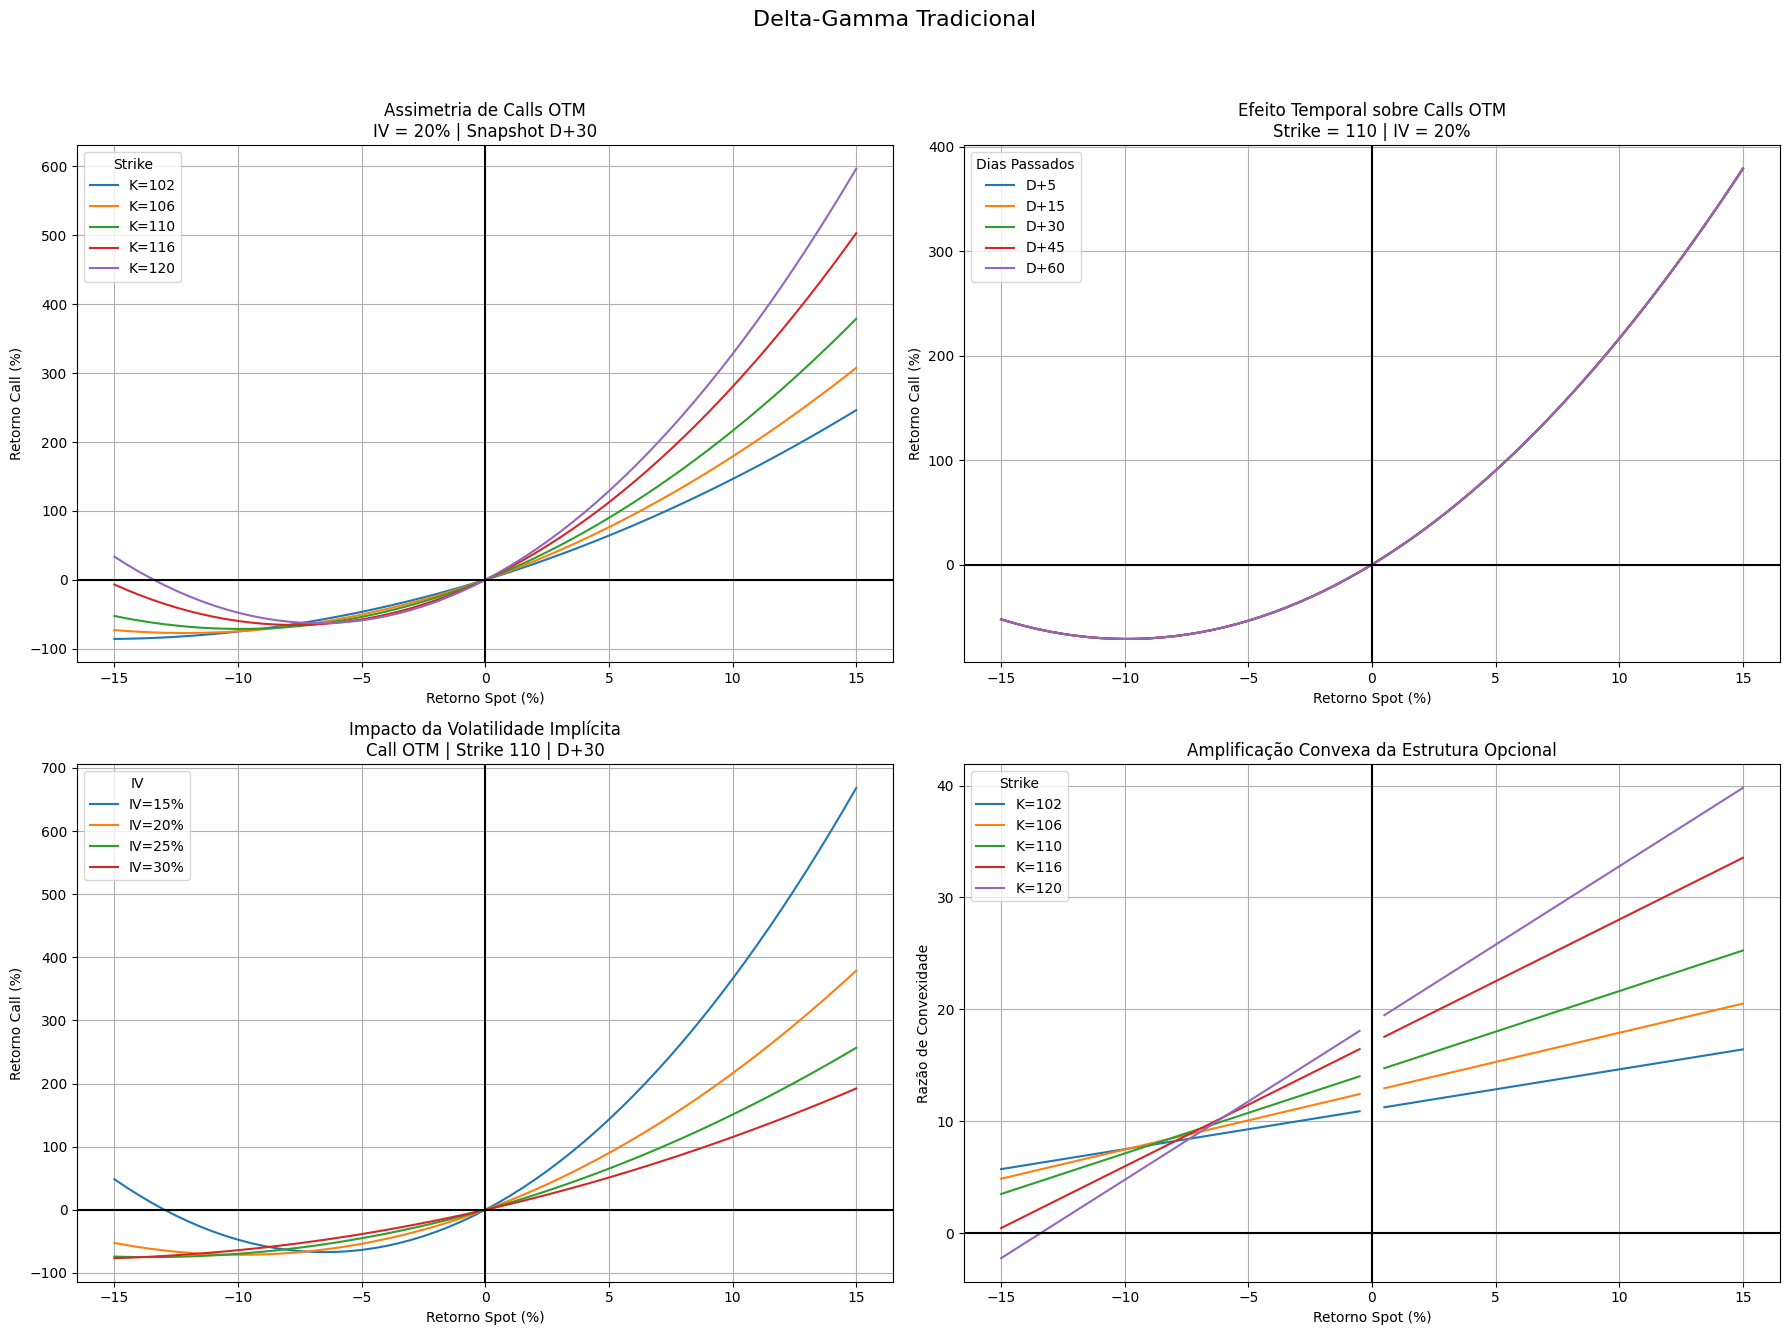


RESUMO ESTATÍSTICO

  Strike    IV Days Passed   DG Call Call Return (%)              \
                                mean            mean         std   
0    102  0.15           5  5.206026       49.514173  137.274258   
1    102  0.15          10  5.206026       49.514173  137.274258   
2    102  0.15          15  5.206026       49.514173  137.274258   
3    102  0.15          20  5.206026       49.514173  137.274258   
4    102  0.15          30  5.206026       49.514173  137.274258   

  Convexity Ratio Theta Daily     Gamma     Delta  
             mean        mean      mean      mean  
0       14.624575   -0.029275  0.044492  0.509222  
1       14.624575   -0.029275  0.044492  0.509222  
2       14.624575   -0.029275  0.044492  0.509222  
3       14.624575   -0.029275  0.044492  0.509222  
4       14.624575   -0.029275  0.044492  0.509222  


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):

    if T <= 0:
        return max(S - K, 0)

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    return (
        S*norm.cdf(d1)
        - K*np.exp(-r*T)*norm.cdf(d2)
    )


def bs_delta(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return (
        norm.pdf(d1)
        /
        (S*sigma*np.sqrt(T))
    )


def bs_theta_call(S, K, T, r, sigma):

    d1 = (
        np.log(S/K)
        + (r + 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    d2 = d1 - sigma*np.sqrt(T)

    theta = (
        -(S*norm.pdf(d1)*sigma)
        /(2*np.sqrt(T))
        -
        r*K*np.exp(-r*T)*norm.cdf(d2)
    )

    return theta/252


# ============================================================
# DELTA-GAMMA TRADICIONAL
# ============================================================

def delta_gamma_price(
        C0,
        delta0,
        gamma0,
        dS):

    pnl = (
        delta0*dS
        +
        0.5*gamma0*(dS**2)
    )

    return C0 + pnl


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

S0 = 100

r = 0.05

# ------------------------------------------------------------
# Volatilidades implícitas
# ------------------------------------------------------------

ivs = [
    0.15,
    0.20,
    0.25,
    0.30
]

# ------------------------------------------------------------
# Calls OTM
# ------------------------------------------------------------

strikes = [
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120
]

# ------------------------------------------------------------
# Estado inicial
# ------------------------------------------------------------

initial_dte = 90

# ------------------------------------------------------------
# Snapshots
# ------------------------------------------------------------

snapshots = [
    5,
    10,
    15,
    20,
    30,
    45,
    60
]

# ------------------------------------------------------------
# Choques
# ------------------------------------------------------------

spot_returns = np.linspace(
    -0.15,
    0.15,
    61
)

# ============================================================
# DATASET
# ============================================================

results = []

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for sigma in ivs:

    for K in strikes:

        # ----------------------------------------------------
        # Greeks congeladas
        # ----------------------------------------------------

        T0 = initial_dte/252

        C0 = bs_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        delta0 = bs_delta(
            S0,
            K,
            T0,
            r,
            sigma
        )

        gamma0 = bs_gamma(
            S0,
            K,
            T0,
            r,
            sigma
        )

        theta0 = bs_theta_call(
            S0,
            K,
            T0,
            r,
            sigma
        )

        # ----------------------------------------------------
        # Evolução temporal
        # ----------------------------------------------------

        for days_passed in snapshots:

            remaining_dte = (
                initial_dte
                - days_passed
            )

            # --------------------------------------------
            # Choques no spot
            # --------------------------------------------

            for ret in spot_returns:

                S_new = S0*(1 + ret)

                dS = S_new - S0

                # ----------------------------------------
                # Delta-Gamma
                # ----------------------------------------

                C_new = delta_gamma_price(
                    C0,
                    delta0,
                    gamma0,
                    dS
                )

                # ----------------------------------------
                # Retornos
                # ----------------------------------------

                spot_return_pct = (
                    ret*100
                )

                call_return_pct = (
                    (C_new - C0)
                    / C0
                )*100

                # ----------------------------------------
                # Convexidade
                # ----------------------------------------

                if abs(
                    spot_return_pct
                ) > 1e-8:

                    convexity_ratio = (
                        call_return_pct
                        /
                        spot_return_pct
                    )

                else:

                    convexity_ratio = np.nan

                # ----------------------------------------
                # Armazenamento
                # ----------------------------------------

                results.append({

                    "IV": sigma,

                    "Strike": K,

                    "Moneyness":
                        round(K/S0,3),

                    "Days Passed":
                        days_passed,

                    "Remaining DTE":
                        remaining_dte,

                    "Spot":
                        S_new,

                    "Spot Return (%)":
                        spot_return_pct,

                    "Initial Call":
                        C0,

                    "DG Call":
                        C_new,

                    "Call Return (%)":
                        call_return_pct,

                    "Convexity Ratio":
                        convexity_ratio,

                    "Delta":
                        delta0,

                    "Gamma":
                        gamma0,

                    "Theta Daily":
                        theta0
                })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print("\n======================================")
print("AMOSTRA DOS RESULTADOS")
print("======================================\n")

print(df.head())

# ============================================================
# GRÁFICOS
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18,14)
)

fig.suptitle(
    "Delta-Gamma Tradicional",
    fontsize=16
)

example_strikes = [
    102,
    106,
    110,
    116,
    120
]

example_days = [
    5,
    15,
    30,
    45,
    60
]

example_ivs = [
    0.15,
    0.20,
    0.25,
    0.30
]

# ============================================================
# PLOT 1
# ASSIMETRIA OTM
# ============================================================

for K in example_strikes:

    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]

    axes[0,0].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"K={K}"
    )

axes[0,0].axhline(0,color='black')
axes[0,0].axvline(0,color='black')

axes[0,0].set_xlabel(
    "Retorno Spot (%)"
)

axes[0,0].set_ylabel(
    "Retorno Call (%)"
)

axes[0,0].set_title(
    "Assimetria de Calls OTM\nIV = 20% | Snapshot D+30"
)


axes[0,0].grid(True)
axes[0,0].legend()

# ============================================================
# PLOT 2
# TEMPO
# ============================================================

for d in example_days:

    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == d)
        &
        (df["IV"] == 0.20)
    ]

    axes[0,1].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"D+{d}"
    )

axes[0,1].axhline(0,color='black')
axes[0,1].axvline(0,color='black')

axes[0,1].set_xlabel(
    "Retorno Spot (%)"
)

axes[0,1].set_ylabel(
    "Retorno Call (%)"
)


axes[0,1].set_title(
    "Efeito Temporal sobre Calls OTM\nStrike = 110 | IV = 20%"
)

axes[0,1].grid(True)
axes[0,1].legend()

# ============================================================
# PLOT 3
# IV
# ============================================================

for sigma_val in example_ivs:

    subset = df[
        (df["Strike"] == 110)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == sigma_val)
    ]

    axes[1,0].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"IV={sigma_val:.0%}"
    )

axes[1,0].axhline(0,color='black')
axes[1,0].axvline(0,color='black')

axes[1,0].set_xlabel(
    "Retorno Spot (%)"
)

axes[1,0].set_ylabel(
    "Retorno Call (%)"
)

axes[1,0].set_title(
    "Impacto da Volatilidade Implícita\nCall OTM | Strike 110 | D+30"
)


axes[1,0].grid(True)
axes[1,0].legend()

# ============================================================
# PLOT 4
# CONVEXIDADE
# ============================================================

for K in example_strikes:

    subset = df[
        (df["Strike"] == K)
        &
        (df["Days Passed"] == 30)
        &
        (df["IV"] == 0.20)
    ]

    axes[1,1].plot(
        subset["Spot Return (%)"],
        subset["Convexity Ratio"],
        label=f"K={K}"
    )

axes[1,1].axhline(0,color='black')
axes[1,1].axvline(0,color='black')

axes[1,1].set_xlabel(
    "Retorno Spot (%)"
)

axes[1,1].set_ylabel(
    "Razão de Convexidade"
)

axes[1,1].set_title(
    "Amplificação Convexa da Estrutura Opcional"
)

axes[1,1].grid(True)
axes[1,1].legend()

plt.tight_layout(
    rect=[0,0.03,1,0.95]
)

axes[0,0].legend(title="Strike")

axes[0,1].legend(title="Dias Passados")

axes[1,0].legend(title="IV")

axes[1,1].legend(title="Strike")

plt.show()

# ============================================================
# RESUMO
# ============================================================

summary = df.groupby([
    "Strike",
    "IV",
    "Days Passed"
]).agg({

    "DG Call":
        "mean",

    "Call Return (%)":
        ["mean","std"],

    "Convexity Ratio":
        "mean",

    "Theta Daily":
        "mean",

    "Gamma":
        "mean",

    "Delta":
        "mean"

}).reset_index()

print("\n======================================")
print("RESUMO ESTATÍSTICO")
print("======================================\n")

print(summary.head())

# Cenário III


AMOSTRA DOS RESULTADOS

     IV  Strike  Moneyness  Days Passed  Remaining DTE  Spot  Spot Return (%)  \
0  0.15     102       1.02            5             85  85.0            -15.0   
1  0.15     102       1.02            5             85  85.5            -14.5   
2  0.15     102       1.02            5             85  86.0            -14.0   
3  0.15     102       1.02            5             85  86.5            -13.5   
4  0.15     102       1.02            5             85  87.0            -13.0   

   Initial Call  Adjusted Call  Call Return (%)  Convexity Ratio  \
0      3.481961       0.848979       -75.617797         5.041186   
1      3.481961       0.775462       -77.729174         5.360633   
2      3.481961       0.713067       -79.521106         5.680079   
3      3.481961       0.661796       -80.993591         5.999525   
4      3.481961       0.621647       -82.146630         6.318972   

   Delta Initial  Gamma Initial  Gamma Effective  Theta Daily  
0       0.50922

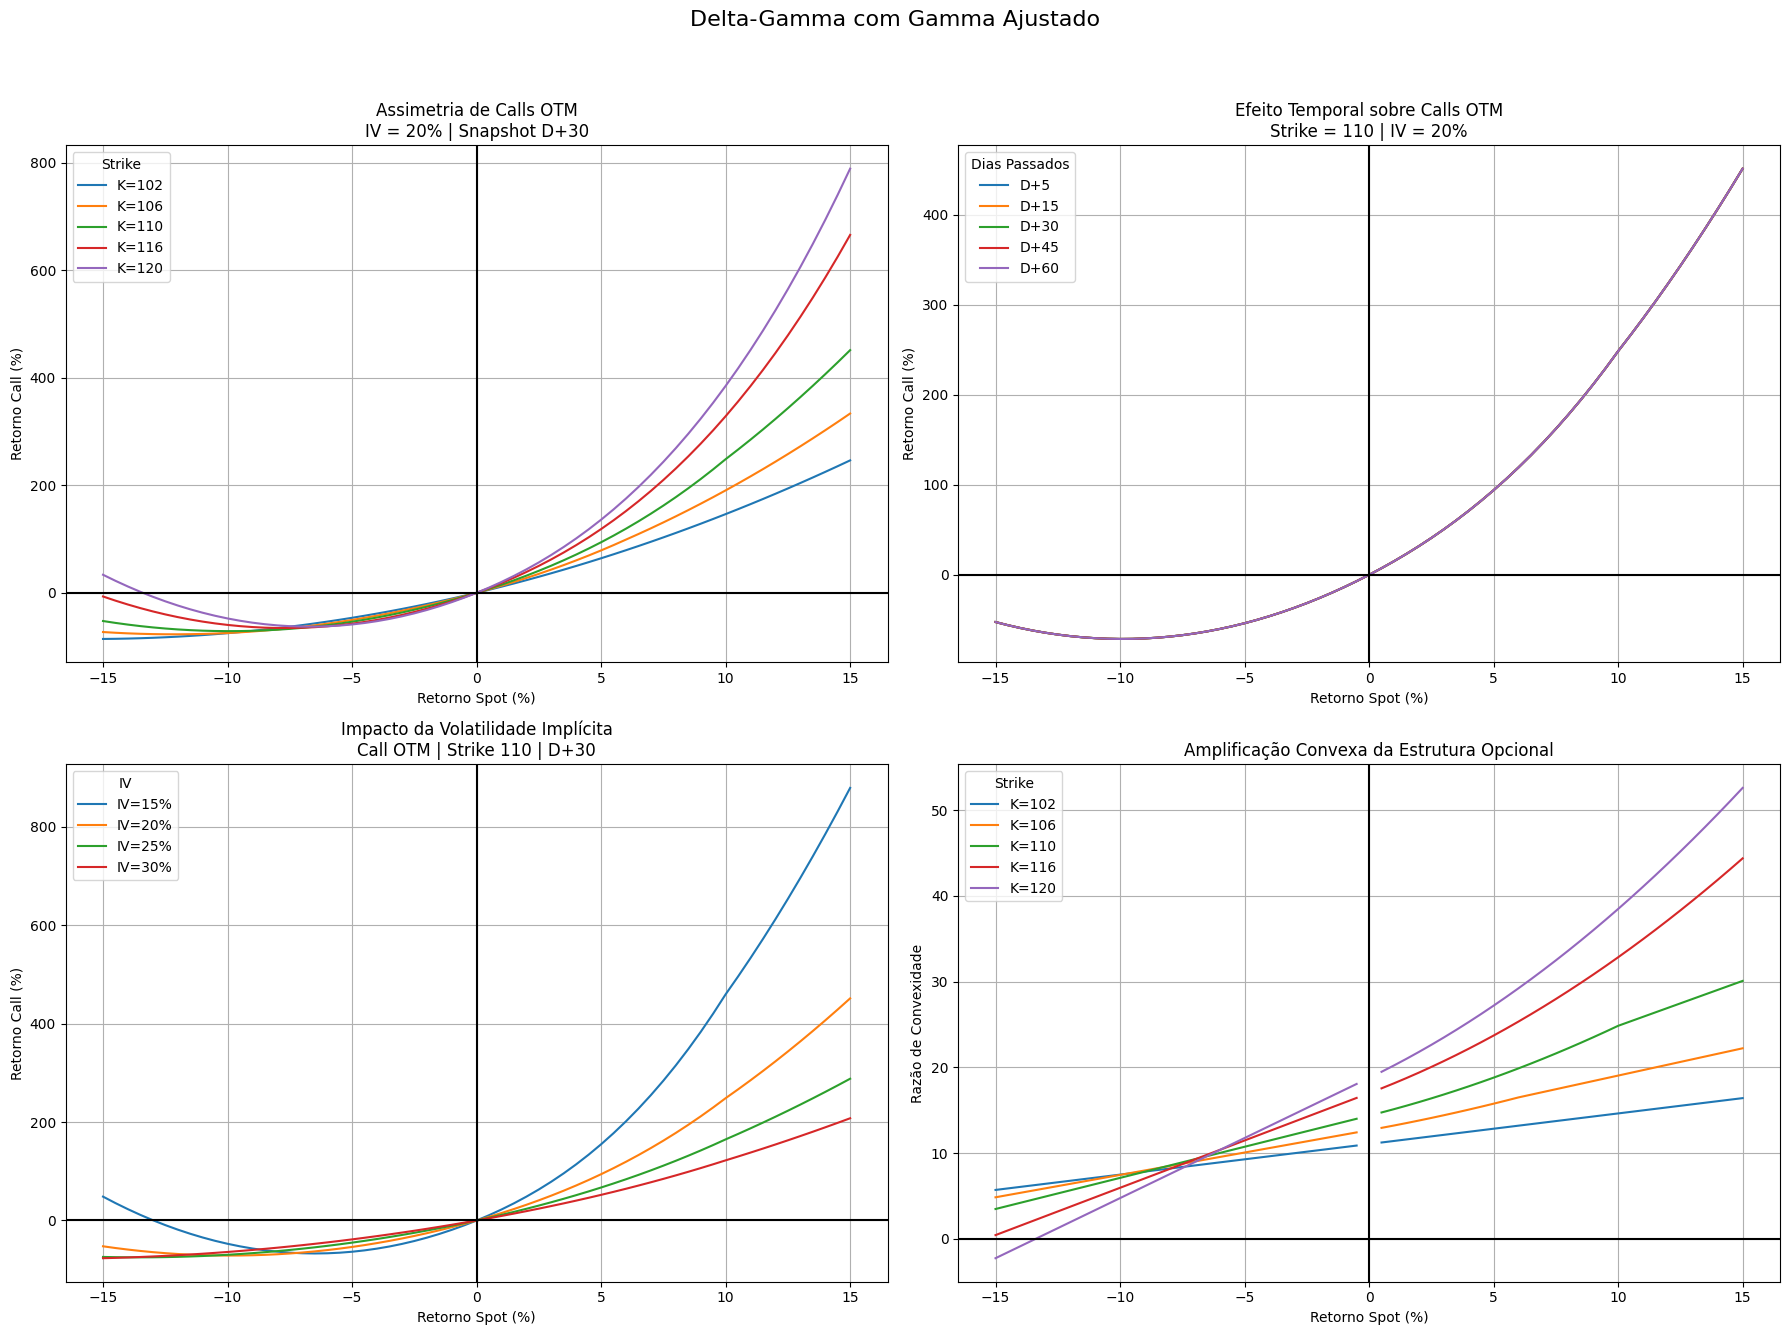

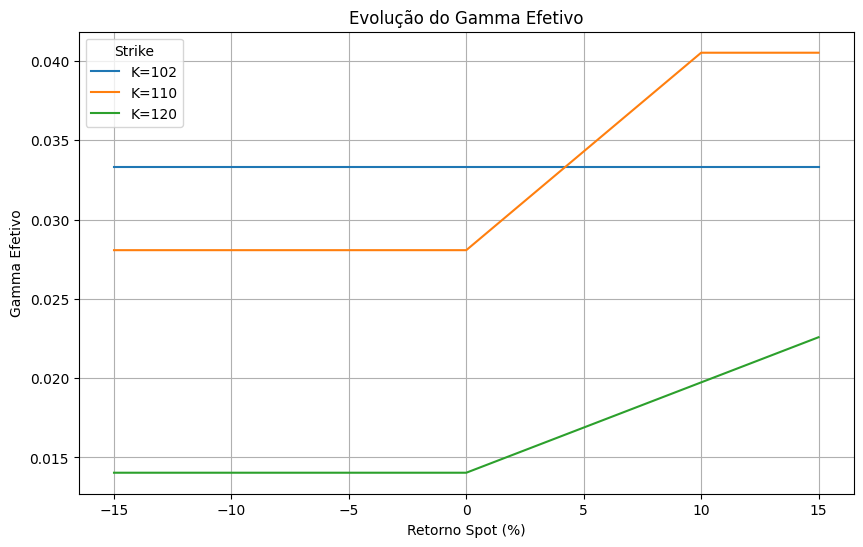


RESUMO ESTATÍSTICO

  Strike    IV Days Passed Adjusted Call Call Return (%)              \
                                    mean            mean         std   
0    102  0.15           5      5.206026       49.514173  137.274258   
1    102  0.15          10      5.206026       49.514173  137.274258   
2    102  0.15          15      5.206026       49.514173  137.274258   
3    102  0.15          20      5.206026       49.514173  137.274258   
4    102  0.15          30      5.206026       49.514173  137.274258   

  Convexity Ratio Theta Daily Gamma Initial Gamma Effective Delta Initial  
             mean        mean          mean            mean          mean  
0       14.624575   -0.029275      0.044492        0.044492      0.509222  
1       14.624575   -0.029275      0.044492        0.044492      0.509222  
2       14.624575   -0.029275      0.044492        0.044492      0.509222  
3       14.624575   -0.029275      0.044492        0.044492      0.509222  
4       14.624575 

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# ============================================================
# BLACK-SCHOLES
# ============================================================

def bs_call(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0)

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )


def bs_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    return norm.cdf(d1)


def bs_gamma(S, K, T, r, sigma):
    if T <= 0:
        return 0.0

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    return norm.pdf(d1) / (S * sigma * np.sqrt(T))


def bs_theta_call(S, K, T, r, sigma):
    if T <= 0:
        return 0.0

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    theta = (
        -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T) * norm.cdf(d2)
    )

    # theta diário
    return theta / 252


# ============================================================
# GAMMA AJUSTADO
# ============================================================

def adjusted_gamma(
        gamma0,
        delta0,
        shock,
        strike_return):

    if strike_return <= 0:
        return gamma0

    if shock <= 0:
        return gamma0

    if shock >= strike_return:
        w = 1.0
    else:
        w = shock / strike_return

    # ------------------------------------
    # Distância até ATM (Delta ≈ 0.5)
    # ------------------------------------

    A = max(
        (0.5 - delta0)/0.5,
        0.0
    )

    return gamma0*(1 + A*w)


def adjusted_delta_gamma_price(C0, delta0, gamma_eff, dS):
    pnl = (
        delta0 * dS
        + 0.5 * gamma_eff * (dS ** 2)
    )
    return C0 + pnl


# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

S0 = 100
r = 0.05

# Volatilidades implícitas anuais
ivs = [0.15, 0.20, 0.25, 0.30]

# Calls OTM moderadas
strikes = [
    102,
    104,
    106,
    108,
    110,
    112,
    114,
    116,
    118,
    120
]

# Opção nasce com 90 DTE
initial_dte = 90

# Snapshots observados
snapshots = [
    5,
    10,
    15,
    20,
    30,
    45,
    60
]

# Choques simétricos no spot
spot_returns = np.linspace(-0.15, 0.15, 61)

# ============================================================
# DATASET
# ============================================================

results = []

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for sigma in ivs:

    for K in strikes:

        # Estado inicial
        T0 = initial_dte / 252

        C0 = bs_call(S0, K, T0, r, sigma)
        delta0 = bs_delta(S0, K, T0, r, sigma)
        gamma0 = bs_gamma(S0, K, T0, r, sigma)
        theta0 = bs_theta_call(S0, K, T0, r, sigma)

        # Retorno necessário para atingir o strike
        strike_return = (K - S0) / S0

        for days_passed in snapshots:

            remaining_dte = initial_dte - days_passed

            # Mantido apenas para espelhar a estrutura do Cenário I
            # No frozen Greeks, o preço base e as sensibilidades não são recalcados por snapshot
            T_remaining = remaining_dte / 252

            for ret in spot_returns:

                S_new = S0 * (1 + ret)
                dS = S_new - S0

                # Gamma ajustado
                gamma_eff = adjusted_gamma(
                    gamma0=gamma0,
                    delta0=delta0,
                    shock=ret,
                    strike_return=strike_return
                )

                # Preço aproximado via Delta-Gamma ajustado
                C_new = adjusted_delta_gamma_price(
                    C0=C0,
                    delta0=delta0,
                    gamma_eff=gamma_eff,
                    dS=dS
                )

                # Retornos
                spot_return_pct = ret * 100
                call_return_pct = ((C_new - C0) / C0) * 100 if C0 != 0 else np.nan

                # Razão de convexidade / amplificação
                if abs(spot_return_pct) > 1e-8:
                    convexity_ratio = call_return_pct / spot_return_pct
                else:
                    convexity_ratio = np.nan

                results.append({
                    "IV": sigma,
                    "Strike": K,
                    "Moneyness": round(K / S0, 3),
                    "Days Passed": days_passed,
                    "Remaining DTE": remaining_dte,
                    "Spot": S_new,
                    "Spot Return (%)": spot_return_pct,
                    "Initial Call": C0,
                    "Adjusted Call": C_new,
                    "Call Return (%)": call_return_pct,
                    "Convexity Ratio": convexity_ratio,
                    "Delta Initial": delta0,
                    "Gamma Initial": gamma0,
                    "Gamma Effective": gamma_eff,
                    "Theta Daily": theta0
                })

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(results)

print("\n======================================")
print("AMOSTRA DOS RESULTADOS")
print("======================================\n")
print(df.head())

# ============================================================
# GRÁFICOS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Delta-Gamma com Gamma Ajustado", fontsize=16)

example_strikes = [102, 106, 110, 116, 120]
example_days = [5, 15, 30, 45, 60]
example_ivs = [0.15, 0.20, 0.25, 0.30]

# ------------------------------------------------------------
# PLOT 1: ASSIMETRIA OTM
# ------------------------------------------------------------
for K in example_strikes:
    subset = df[
        (df["Strike"] == K) &
        (df["Days Passed"] == 30) &
        (df["IV"] == 0.20)
    ]
    axes[0, 0].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"K={K}"
    )

axes[0, 0].axhline(0, color='black')
axes[0, 0].axvline(0, color='black')
axes[0, 0].set_xlabel("Retorno Spot (%)")
axes[0, 0].set_ylabel("Retorno Call (%)")
axes[0, 0].set_title("Assimetria de Calls OTM\nIV = 20% | Snapshot D+30")
axes[0, 0].grid(True)
axes[0, 0].legend(title="Strike")

# ------------------------------------------------------------
# PLOT 2: IMPACTO DO TEMPO
# ------------------------------------------------------------
for d in example_days:
    subset = df[
        (df["Strike"] == 110) &
        (df["Days Passed"] == d) &
        (df["IV"] == 0.20)
    ]
    axes[0, 1].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"D+{d}"
    )

axes[0, 1].axhline(0, color='black')
axes[0, 1].axvline(0, color='black')
axes[0, 1].set_xlabel("Retorno Spot (%)")
axes[0, 1].set_ylabel("Retorno Call (%)")
axes[0, 1].set_title("Efeito Temporal sobre Calls OTM\nStrike = 110 | IV = 20%")
axes[0, 1].grid(True)
axes[0, 1].legend(title="Dias Passados")

# ------------------------------------------------------------
# PLOT 3: IMPACTO DA VOLATILIDADE
# ------------------------------------------------------------
for sigma_val in example_ivs:
    subset = df[
        (df["Strike"] == 110) &
        (df["Days Passed"] == 30) &
        (df["IV"] == sigma_val)
    ]
    axes[1, 0].plot(
        subset["Spot Return (%)"],
        subset["Call Return (%)"],
        label=f"IV={sigma_val:.0%}"
    )

axes[1, 0].axhline(0, color='black')
axes[1, 0].axvline(0, color='black')
axes[1, 0].set_xlabel("Retorno Spot (%)")
axes[1, 0].set_ylabel("Retorno Call (%)")
axes[1, 0].set_title("Impacto da Volatilidade Implícita\nCall OTM | Strike 110 | D+30")
axes[1, 0].grid(True)
axes[1, 0].legend(title="IV")

# ------------------------------------------------------------
# PLOT 4: CONVEXIDADE / AMPLIFICAÇÃO
# ------------------------------------------------------------
for K in example_strikes:
    subset = df[
        (df["Strike"] == K) &
        (df["Days Passed"] == 30) &
        (df["IV"] == 0.20)
    ]
    axes[1, 1].plot(
        subset["Spot Return (%)"],
        subset["Convexity Ratio"],
        label=f"K={K}"
    )

axes[1, 1].axhline(0, color='black')
axes[1, 1].axvline(0, color='black')
axes[1, 1].set_xlabel("Retorno Spot (%)")
axes[1, 1].set_ylabel("Razão de Convexidade")
axes[1, 1].set_title("Amplificação Convexa da Estrutura Opcional")
axes[1, 1].grid(True)
axes[1, 1].legend(title="Strike")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# GRÁFICO EXTRA: GAMMA EFETIVO
# ============================================================

plt.figure(figsize=(10, 6))

for K in [102, 110, 120]:
    subset = df[
        (df["Strike"] == K) &
        (df["Days Passed"] == 30) &
        (df["IV"] == 0.20)
    ]
    plt.plot(
        subset["Spot Return (%)"],
        subset["Gamma Effective"],
        label=f"K={K}"
    )

plt.title("Evolução do Gamma Efetivo")
plt.xlabel("Retorno Spot (%)")
plt.ylabel("Gamma Efetivo")
plt.grid(True)
plt.legend(title="Strike")
plt.show()

# ============================================================
# RESUMO ESTATÍSTICO
# ============================================================

summary = df.groupby([
    "Strike",
    "IV",
    "Days Passed"
]).agg({
    "Adjusted Call": "mean",
    "Call Return (%)": ["mean", "std"],
    "Convexity Ratio": "mean",
    "Theta Daily": "mean",
    "Gamma Initial": "mean",
    "Gamma Effective": "mean",
    "Delta Initial": "mean"
}).reset_index()

print("\n======================================")
print("RESUMO ESTATÍSTICO")
print("======================================\n")
print(summary.head())

# BackTesting

In [2]:
"""
TCC Backtesting — SPX Options
Comparação entre exposição direta ao spot e calls OTM
sob três metodologias de avaliação (Full Valuation, Delta-Gamma, Gamma Ajustado)

Dados: https://github.com/Osstrinha/TCC
"""

import io
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# ── 0. CONFIGURAÇÕES GERAIS ─────────────────────────────────────────────────

GITHUB_RAW = "https://raw.githubusercontent.com/Osstrinha/TCC/main/"
MESES = [f"spx_eod_2023{m:02d}.zip" for m in range(1, 13)]

JANELAS = {
    "Jan→Abr (alta gradual)":   ("2023-01-04", "2023-04-21"),
    "Abr→Jun (stress SVB)":     ("2023-04-03", "2023-06-30"),
    "Ago→Out (queda/retomada)": ("2023-08-01", "2023-10-31"),
}

MONEYNESS_ALVO = [0.02, 0.05, 0.10, 0.15]

# Níveis de stop usados para CALIBRAR o tamanho da posição
# (não são mais "alvos a serem batidos" — são hipóteses de risco do investidor)
STOPS_CALIBRACAO = [0.05, 0.10, 0.15]

SNAPSHOT_DIAS = [0, 15, 30, 45, 60, 75, 90]
CAPITAL_W = 100_000

CORES_CEN  = {'I': '#2196F3', 'II': '#FF9800', 'III': '#4CAF50'}
LABELS_CEN = {'I': 'Full Valuation (real)', 'II': 'Δ-Γ Tradicional',
              'III': 'Δ-Γ Ajustado'}
LABELS_MONO = {0.02: '+2% OTM', 0.05: '+5% OTM',
               0.10: '+10% OTM', 0.15: '+15% OTM'}

# ── 1. CARGA DE DADOS ───────────────────────────────────────────────────────

def carregar_mes(nome_zip: str) -> pd.DataFrame:
    url = GITHUB_RAW + nome_zip
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        nome_txt = z.namelist()[0]
        with z.open(nome_txt) as f:
            df = pd.read_csv(f, skipinitialspace=True)
    return df


def carregar_todos() -> pd.DataFrame:
    print("Carregando dados do GitHub...")
    frames = []
    for mes in MESES:
        print(f"  {mes}...", end=" ")
        try:
            df = carregar_mes(mes)
            frames.append(df)
            print(f"{len(df):,} linhas")
        except Exception as e:
            print(f"ERRO: {e}")
    df = pd.concat(frames, ignore_index=True)
    print(f"\nTotal: {len(df):,} linhas")
    return df


def limpar(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [c.strip().replace('[', '').replace(']', '') for c in df.columns]
    df['QUOTE_DATE']  = pd.to_datetime(df['QUOTE_DATE'].str.strip())
    df['EXPIRE_DATE'] = pd.to_datetime(df['EXPIRE_DATE'].str.strip())

    for col in ['UNDERLYING_LAST', 'STRIKE', 'DTE',
                'C_DELTA', 'C_GAMMA', 'C_THETA', 'C_IV',
                'C_BID', 'C_ASK', 'C_LAST']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['C_MID'] = (df['C_BID'] + df['C_ASK']) / 2

    df = df[
        (df['C_BID'] > 0) &
        (df['C_IV']  > 0) &
        (df['C_DELTA'].between(0, 1)) &
        (df['DTE'] >= 0)
    ].copy()

    return df.reset_index(drop=True)

# ── 2. SELEÇÃO DE CONTRATOS ──────────────────────────────────────────────────

def selecionar_strikes(df: pd.DataFrame, d0: str, expire: str) -> pd.DataFrame:
    d0 = pd.Timestamp(d0)
    exp = pd.Timestamp(expire)

    sub = df[df['QUOTE_DATE'] == d0].copy()
    if sub.empty:
        raise ValueError(f"D0 {d0} não encontrado nos dados.")

    vencimentos = sub['EXPIRE_DATE'].unique()
    diffs = np.abs(pd.Series(vencimentos) - exp)
    expire_real = vencimentos[diffs.argmin()]

    sub = sub[sub['EXPIRE_DATE'] == expire_real].copy()
    spot = sub['UNDERLYING_LAST'].iloc[0]
    sub['MONEYNESS'] = (sub['STRIKE'] - spot) / spot
    dte_d0 = sub['DTE'].iloc[0]

    resultado = []
    for alvo in MONEYNESS_ALVO:
        candidatos = sub[sub['MONEYNESS'] > 0].copy()
        idx = (candidatos['MONEYNESS'] - alvo).abs().idxmin()
        row = candidatos.loc[idx].copy()
        row['MONEYNESS_ALVO'] = alvo
        row['SPOT_D0'] = spot
        row['EXPIRE_REAL'] = expire_real
        row['DTE_D0'] = dte_d0
        resultado.append(row)

    return pd.DataFrame(resultado)


def buscar_snapshots(df: pd.DataFrame, strikes_d0: pd.DataFrame,
                      d0: str) -> pd.DataFrame:
    """Para cada contrato, busca o preço real e o DTE restante em cada
    snapshot — independentemente do retorno do spot observado."""
    d0 = pd.Timestamp(d0)
    datas_disponiveis = sorted(df['QUOTE_DATE'].unique())

    registros = []
    for _, contrato in strikes_d0.iterrows():
        strike     = contrato['STRIKE']
        expire     = contrato['EXPIRE_REAL']
        spot_d0    = contrato['SPOT_D0']
        mono_alvo  = contrato['MONEYNESS_ALVO']
        premio_d0  = contrato['C_MID']
        delta_d0   = contrato['C_DELTA']
        gamma_d0   = contrato['C_GAMMA']
        theta_d0   = contrato['C_THETA']
        iv_d0      = contrato['C_IV']
        dte_d0     = contrato['DTE_D0']

        for dias in SNAPSHOT_DIAS:
            alvo_dt = d0 + pd.Timedelta(days=dias)
            futuros = [d for d in datas_disponiveis if d >= alvo_dt]
            if not futuros:
                continue
            data_snap = futuros[0]

            snap = df[
                (df['QUOTE_DATE']  == data_snap) &
                (df['STRIKE']      == strike)     &
                (df['EXPIRE_DATE'] == expire)
            ]
            if snap.empty:
                continue

            row = snap.iloc[0]
            spot_snap = row['UNDERLYING_LAST']
            premio_snap_real = row['C_MID']
            iv_snap = row['C_IV']
            dte_snap = row['DTE']
            retorno_spot = (spot_snap - spot_d0) / spot_d0

            registros.append({
                'DIAS':             dias,
                'DTE_D0':           dte_d0,
                'DTE_RESTANTE':     dte_snap,
                'DIAS_DECORRIDOS_REAL': dte_d0 - dte_snap,
                'MONEYNESS_ALVO':   mono_alvo,
                'STRIKE':           strike,
                'SPOT_D0':          spot_d0,
                'SPOT_SNAP':        spot_snap,
                'RETORNO_SPOT':     retorno_spot,
                'PREMIO_D0':        premio_d0,
                'PREMIO_SNAP_REAL': premio_snap_real,
                'IV_D0':            iv_d0,
                'IV_SNAP':          iv_snap,
                'DELTA_D0':         delta_d0,
                'GAMMA_D0':         gamma_d0,
                'THETA_D0':         theta_d0,
            })

    return pd.DataFrame(registros)

# ── 3. MODELOS DE AVALIAÇÃO ──────────────────────────────────────────────────

def variacao_cenario_II(delta, gamma, delta_s):
    """Delta-Gamma tradicional: gregas calculadas e congeladas no D0."""
    return delta * delta_s + 0.5 * gamma * delta_s**2


def variacao_cenario_III(delta, gamma, delta_s, spot_d0, strike):
    """Delta-Gamma com Gamma ajustado."""
    C_K = (strike - spot_d0) / spot_d0
    if C_K <= 0:
        return variacao_cenario_II(delta, gamma, delta_s)

    C_rel = delta_s / spot_d0
    w = min(C_rel / C_K, 1.0) if C_rel > 0 else 0.0
    A = (0.5 - delta) / 0.5
    gamma_star = gamma * (1 + A * w)
    return delta * delta_s + 0.5 * gamma_star * delta_s**2

# ── 4. CALIBRAÇÃO ────────────────────────────────────────────────────────────

def calibrar_n(delta, gamma, spot_d0, strike, Y, cenario):
    """
    n tal que a perda estimada da posição em opção, num choque
    hipotético de -Y%, iguale a perda do spot no mesmo choque.

    O calibre é fixado UMA VEZ no D0 e usado para todos os snapshots
    subsequentes — é a aposta inicial do investidor, baseada na sua
    tolerância a perda, e não muda com o tempo.
    """
    delta_s_neg = -Y * spot_d0
    perda_ref = CAPITAL_W * Y

    if cenario in ('I', 'II'):
        dv = abs(variacao_cenario_II(delta, gamma, delta_s_neg))
    elif cenario == 'III':
        dv = abs(variacao_cenario_III(delta, gamma, delta_s_neg, spot_d0, strike))
    else:
        raise ValueError(cenario)

    perda_por_contrato = dv * 100
    if perda_por_contrato <= 0:
        return np.nan
    return perda_ref / perda_por_contrato

# ── 5. MATRIZ COMPLETA DE RESULTADOS ────────────────────────────────────────

def construir_matriz(snaps_por_strike: dict, janela: str) -> pd.DataFrame:
    """
    Para CADA combinação de moneyness × snapshot × stop de calibração ×
    cenário, reporta o resultado — sem filtrar por "bateu o alvo ou não".

    n é calibrado uma única vez por (moneyness, stop, cenário) usando os
    dados do D0, e então aplicado a TODOS os snapshots dessa mesma série,
    mostrando a evolução completa da aposta no tempo.
    """
    linhas = []

    for mono, snaps in snaps_por_strike.items():
        if snaps.empty:
            continue
        d0_row = snaps[snaps['DIAS'] == 0]
        if d0_row.empty:
            continue
        d0_row = d0_row.iloc[0]

        delta0, gamma0 = d0_row['DELTA_D0'], d0_row['GAMMA_D0']
        spot_d0, strike, premio_d0 = (d0_row['SPOT_D0'], d0_row['STRIKE'],
                                       d0_row['PREMIO_D0'])
        dte_d0 = d0_row['DTE_D0']

        for Y in STOPS_CALIBRACAO:
            ns = {cen: calibrar_n(delta0, gamma0, spot_d0, strike, Y, cen)
                  for cen in ['I', 'II', 'III']}

            for _, snap in snaps.iterrows():
                delta_s = snap['SPOT_SNAP'] - spot_d0
                ret_spot = snap['RETORNO_SPOT']
                dte_restante = snap['DTE_RESTANTE']
                dias = snap['DIAS']

                for cen in ['I', 'II', 'III']:
                    n = ns[cen]
                    if np.isnan(n) or n <= 0:
                        continue

                    if cen == 'I':
                        dv = snap['PREMIO_SNAP_REAL'] - premio_d0
                    elif cen == 'II':
                        dv = variacao_cenario_II(delta0, gamma0, delta_s)
                    else:
                        dv = variacao_cenario_III(delta0, gamma0, delta_s,
                                                  spot_d0, strike)

                    pnl_opcao = n * dv * 100
                    pnl_spot  = CAPITAL_W * ret_spot
                    custo     = n * premio_d0 * 100

                    linhas.append({
                        'JANELA':         janela,
                        'MONEYNESS_ALVO': mono,
                        'STOP_CALIBRADO': Y,
                        'CENARIO':        cen,
                        'DIAS':           dias,
                        'DTE_D0':         dte_d0,
                        'DTE_RESTANTE':   dte_restante,
                        'RETORNO_SPOT':   ret_spot,
                        'N_CONTRATOS':    n,
                        'CUSTO_OPCAO':    custo,
                        'PNL_OPCAO':      pnl_opcao,
                        'PNL_SPOT':       pnl_spot,
                        'RET_OPCAO':      pnl_opcao / CAPITAL_W,
                        'RET_SPOT':       ret_spot,
                        'VANTAGEM':       (pnl_opcao - pnl_spot) / CAPITAL_W,
                    })

    return pd.DataFrame(linhas)

# ── 6. VISUALIZAÇÕES ─────────────────────────────────────────────────────────

def plot_evolucao_por_vertice(matriz: pd.DataFrame, janela: str, stop: float):
    """
    Grid 2×2 (um por moneyness). Em cada painel, eixo X = dias decorridos,
    eixo Y = retorno sobre capital. Mostra a evolução completa da aposta
    calibrada para aquele stop, lado a lado com o spot, pelos três cenários.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Evolução da Aposta Calibrada (Stop {stop*100:.0f}%) — {janela}",
                 fontsize=13)

    sub = matriz[matriz['STOP_CALIBRADO'] == stop]

    for ax, mono in zip(axes.flat, MONEYNESS_ALVO):
        s2 = sub[sub['MONEYNESS_ALVO'] == mono].sort_values('DIAS')
        if s2.empty:
            ax.set_visible(False)
            continue

        for cen in ['I', 'II', 'III']:
            sc = s2[s2['CENARIO'] == cen]
            ax.plot(sc['DIAS'], sc['RET_OPCAO'] * 100,
                    color=CORES_CEN[cen], marker='o', ms=5,
                    label=LABELS_CEN[cen])

        ref = s2[s2['CENARIO'] == 'I']
        ax.plot(ref['DIAS'], ref['RET_SPOT'] * 100,
                'k--', marker='s', ms=4, label='Spot puro')

        ax.axhline(0, color='gray', lw=0.6)
        ax.set_title(LABELS_MONO[mono], fontsize=11)
        ax.set_xlabel('Dias desde D0')
        ax.set_ylabel('Retorno sobre Capital (%)')
        ax.legend(fontsize=7)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    plt.tight_layout()
    fname = f"evolucao_{janela[:3].lower()}_stop{int(stop*100)}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f"  Salvo: {fname}")
    plt.close()


def plot_heatmap_vantagem(matriz: pd.DataFrame, janela: str, cenario: str = 'I'):
    """
    Heatmap: linhas = moneyness, colunas = dias, células = vantagem média
    da opção sobre o spot (em pontos percentuais de capital), para um
    cenário de avaliação fixo. Um painel por stop de calibração.
    """
    sub = matriz[matriz['CENARIO'] == cenario]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f"Vantagem da Opção sobre o Spot — {LABELS_CEN[cenario]}\n"
                 f"Janela: {janela}", fontsize=12)

    for ax, stop in zip(axes, STOPS_CALIBRACAO):
        s = sub[sub['STOP_CALIBRADO'] == stop]
        pivot = s.pivot_table(index='MONEYNESS_ALVO', columns='DIAS',
                              values='VANTAGEM', aggfunc='mean') * 100
        pivot.index = [LABELS_MONO[m] for m in pivot.index]

        im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto',
                       vmin=-20, vmax=20)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=9)
        ax.set_xlabel('Dias decorridos')
        ax.set_title(f'Stop calibrado: {stop*100:.0f}%')

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                           fontsize=7,
                           color='black' if abs(val) < 12 else 'white')

        plt.colorbar(im, ax=ax, label='Vantagem (p.p. de capital)')

    plt.tight_layout()
    fname = f"heatmap_{janela[:3].lower()}_{cenario}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    print(f"  Salvo: {fname}")
    plt.close()


def tabela_resumo_vertices(matriz: pd.DataFrame, janela: str) -> pd.DataFrame:
    """
    Tabela texto: para cada vértice (moneyness, stop, dias), mostra o
    retorno do spot observado, e o retorno de cada cenário — permitindo
    ver, vértice a vértice, se a aposta em opção estava "melhor" ou não.
    """
    print(f"\n{'='*90}")
    print(f"MATRIZ COMPLETA DE VÉRTICES — {janela}")
    print(f"{'='*90}")

    for mono in MONEYNESS_ALVO:
        for stop in STOPS_CALIBRACAO:
            sub = matriz[
                (matriz['MONEYNESS_ALVO'] == mono) &
                (matriz['STOP_CALIBRADO'] == stop)
            ]
            if sub.empty:
                continue

            print(f"\n--- {LABELS_MONO[mono]} | Stop calibrado: {stop*100:.0f}% ---")
            pivot = sub.pivot_table(index='DIAS', columns='CENARIO',
                                    values='RET_OPCAO') * 100
            pivot['Spot'] = sub.groupby('DIAS')['RET_SPOT'].mean() * 100
            pivot.columns = [LABELS_CEN.get(c, c) for c in pivot.columns]
            print(pivot.round(1).to_string())

# ── 7. PIPELINE PRINCIPAL ────────────────────────────────────────────────────

def main():
    df_raw = carregar_todos()
    df = limpar(df_raw)

    todas_matrizes = []

    for janela, (d0, expire) in JANELAS.items():
        print(f"\n{'='*60}")
        print(f"JANELA: {janela}")
        print(f"  D0={d0}  Vencimento alvo={expire}")

        try:
            strikes = selecionar_strikes(df, d0, expire)
        except Exception as e:
            print(f"  ERRO ao selecionar strikes: {e}")
            continue

        print(f"  DTE no D0: {strikes['DTE_D0'].iloc[0]:.0f} dias")
        print(f"  Strikes selecionados:")
        for _, r in strikes.iterrows():
            print(f"    {LABELS_MONO[r['MONEYNESS_ALVO']]}: K={r['STRIKE']:.0f}  "
                  f"Δ={r['C_DELTA']:.3f}  Γ={r['C_GAMMA']:.4f}  "
                  f"IV={r['C_IV']:.1%}  Prêmio={r['C_MID']:.2f}")

        snaps_todos = buscar_snapshots(df, strikes, d0)

        # Avisa se algum snapshot ficou com DTE restante muito baixo
        baixo_dte = snaps_todos[snaps_todos['DTE_RESTANTE'] < 10]
        if not baixo_dte.empty:
            print(f"  ATENÇÃO: {len(baixo_dte)} snapshots com DTE restante < 10 dias "
                  f"(perto do vencimento, interpretar com cautela)")

        snaps_por_strike = {
            mono: snaps_todos[snaps_todos['MONEYNESS_ALVO'] == mono]
            for mono in MONEYNESS_ALVO
        }

        matriz = construir_matriz(snaps_por_strike, janela)
        if matriz.empty:
            print("  Matriz vazia para essa janela.")
            continue

        todas_matrizes.append(matriz)

        print("  Gerando gráficos...")
        for stop in STOPS_CALIBRACAO:
            plot_evolucao_por_vertice(matriz, janela, stop)
        plot_heatmap_vantagem(matriz, janela, cenario='I')
        plot_heatmap_vantagem(matriz, janela, cenario='II')

        tabela_resumo_vertices(matriz, janela)

    df_final = pd.concat(todas_matrizes, ignore_index=True)
    df_final.to_csv("tcc_resultados_v3.csv", index=False)
    print("\n\nResultados salvos em tcc_resultados_v3.csv")
    print(f"Total de linhas: {len(df_final):,}")


if __name__ == "__main__":
    main()

Carregando dados do GitHub...
  spx_eod_202301.zip... 143,907 linhas
  spx_eod_202302.zip... 147,515 linhas
  spx_eod_202303.zip... 177,860 linhas
  spx_eod_202304.zip... 144,144 linhas
  spx_eod_202305.zip... 162,133 linhas
  spx_eod_202306.zip... 166,002 linhas
  spx_eod_202307.zip... 163,265 linhas
  spx_eod_202308.zip... 188,130 linhas
  spx_eod_202309.zip... 168,847 linhas
  spx_eod_202310.zip... 187,270 linhas
  spx_eod_202311.zip... 182,236 linhas
  spx_eod_202312.zip... 177,774 linhas

Total: 2,009,083 linhas

JANELA: Jan→Abr (alta gradual)
  D0=2023-01-04  Vencimento alvo=2023-04-21
  DTE no D0: 107 dias
  Strikes selecionados:
    +2% OTM: K=3930  Δ=0.487  Γ=0.0010  IV=20.4%  Prêmio=153.55
    +5% OTM: K=4050  Δ=0.372  Γ=0.0010  IV=19.2%  Prêmio=97.65
    +10% OTM: K=4240  Δ=0.201  Γ=0.0008  IV=17.7%  Prêmio=39.80
    +15% OTM: K=4425  Δ=0.088  Γ=0.0004  IV=16.8%  Prêmio=13.80
  Gerando gráficos...
  Salvo: evolucao_jan_stop5.png
  Salvo: evolucao_jan_stop10.png
  Salvo: evol